# Master Notebook — Active Learning for Thermal Comfort

**MSc AI dissertation | University of Bath**  
**Project:** *Designing Human–AI Decision Support for Digital Twins of Modernist Heritage Buildings*

## Research question

> How can a digital twin system, using active learning on T+RH data, learn when and how to query occupant comfort preferences in order to provide interpretable, personalised recommendations that support informed human decision-making in a heritage building context?

The operative word is *proxy*: the sub-question is the empirical one this notebook tests, while the formal question is a *design* question, so a null on the sub-question forms part of the answer rather than falsifying it - and neither establishes real-occupant accuracy or human-interface effectiveness.

## What this master notebook contains

| Step | Evidence in this notebook | Why it is needed |
|---|---|---|
| 1. Scope and reproducibility | Fixed configuration, seeds and run provenance | Prevents post-hoc result selection |
| 2. Bath ingestion and EDA | Coverage, sensor profiles and gaps | Establishes what was actually measured |
| 3. Synthetic comfort target | PMV, clothing calibration and noise | Documents the proxy label and its assumptions |
| 4. Learnability pre-flight | Signal, noise, ceiling and headroom | Tests whether AL has predictable structure to exploit |
| 5. Experimental design | Temporal split, pool, test set and baseline | Prevents leakage and enables a fair comparison |
| 6. The active-learning loop | Seed, score, select, query, retrain | Defines the mechanism being tested |
| 7. Active-learning evaluation | Entropy versus random over matched seeds | Tests label efficiency rather than accuracy alone |
| 8. Three-stage assessment | Controlled, LaSDPC and Bath balanced results | Separates software capability from real-data effectiveness |
| 9. Query and SHAP evidence | Composition, stability and retrospective explanations | Examines the proxy behaviour, not only scores |
| 10. Validation and robustness | Per-class, calibration, ablation, sensitivity and abstention | Attempts to falsify the preferred interpretation |
| 11. Conclusion and open decisions | Claims, limitations and supervisor-dependent branches | Defines what is complete and what remains unresolved |


## Scope boundary

| In scope | Out of scope |
|---|---|
| T+RH active-learning patterns | Real-occupant comfort accuracy |
| Synthetic PMV feedback | Human-subjects or usability evaluation |
| Entropy versus random querying | Production deployment or autonomous control |
| Query behaviour and audit evidence | Claims about what people would trust or prefer |

Only indoor temperature and RH are model features. Outdoor temperature informs the Bath clothing
assumption only. The Streamlit dashboard is a demonstration artefact, not a research object.

## How to read the code and outputs

Every executable cell is surrounded by two teaching notes:

1. **Code explanation** — purpose, operations and methodological justification.
2. **Output explanation** — what was produced, what it means and what it cannot establish.

All computation imports the tested implementation under `dissertation_code/`. The latest full test
run passed **115 tests**. The expensive Bath and LaSDPC repeated experiments are loaded from frozen
CSV outputs; the notebook does not rerun them unless the explicitly commented regeneration lines are
enabled.


---
## End-to-end design and justification

```text
Real Bath and LaSDPC T+RH
        -> validated, paired observations
        -> PMV plus documented synthetic disagreement
        -> initial labelled seed
        -> Random Forest prediction and entropy
        -> entropy query or matched random query
        -> reveal synthetic label and retrain
        -> balanced metrics, learning curves and label efficiency
        -> query composition, stability and retrospective SHAP audit evidence
```

### Why this design was selected

| Decision | Selected approach | Reason | Rejected or bounded alternative |
|---|---|---|---|
| Features | Indoor temperature + RH | Agreed PoC boundary; available in both datasets | CO2/air quality remain context only |
| Feedback | PMV + calibrated Gaussian noise | Reproducible proxy without human-subjects data | Real votes require ethics and are future work |
| Learner | Random Forest | Works with limited labels and supports probabilities/SHAP | Deep/RL approaches require more data and reduce auditability |
| Query strategy | Predictive entropy | Direct, auditable uncertainty ranking | Random is retained as the null baseline |
| Primary metrics | Balanced accuracy and macro-F1 | Protect against majority-class artefacts | Raw accuracy remains secondary |
| Evaluation | Controlled + LaSDPC + Bath | Separates implementation capability from transfer | One favourable dataset cannot prove the whole claim |
| Interpretation | Query logs + retrospective SHAP | Makes selection behaviour inspectable | No selection-time causal claim without saved snapshots |

This notebook is the master narrative. The three focused supporting notebooks retain deeper evidence:
`bath_signal_variation_justification.ipynb`, `three_stage_active_learning_comparison.ipynb`, and
`professor_results_review.ipynb`.


### Code explanation: initialise reproducible analysis

**Purpose.** Import the tested project modules and fix every random source.

**What the code does.** The cell loads numerical/data libraries, the Bath pipeline, comfort and evaluation packages, sets readable display options, and calls the shared seeding helper.

**Why this step is justified.** A repeated AL comparison is only auditable when identical code and recorded seeds reproduce sampling and model randomness.

In [ ]:
import logging

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from dissertation_code import config, pipeline
from dissertation_code.comfort import clothing
from dissertation_code.comfort import pmv as pmv_model
from dissertation_code.comfort import synthetic_labels as sl
from dissertation_code.data import bath, sampling, schema, sources
from dissertation_code.evaluation import (
    analysis,
    experiment,
    plots,
    robustness, 
    validation,
)
from dissertation_code.model import active_learning as al
from dissertation_code.utils.seeding import make_reproducible

logging.basicConfig(level=logging.WARNING, format="%(message)s")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

make_reproducible()  # seeds numpy + random from config.RANDOM_SEED
print(f"random seed: {config.RANDOM_SEED}")

random seed: 42


#### Output explanation

**What the output is.** The configured random seed, 42, is printed.

**What the output means.** All later sampling, synthetic votes and model initialisation begin from the documented reproducibility anchor.

**Interpretation boundary.** A fixed seed makes this run repeatable; evidence still comes from ten matched experiment seeds rather than one favourable run.

---
# 1. Data

Four quarterly workbooks from the Tinytag loggers. Two properties of this export drive the
loader:

1. **Temperature and humidity share a row and timestamp.** Unlike the earlier LaSDPC dataset —
   where they came from separate devices logging seconds apart — pairing here is native, so no
   resampling is applied.
2. **Sheet names drift between workbooks.** The same sensor appears as `erht2_outsidefront`,
   `erht2 external front` and `erht2_ExternalFront`; the hall is `rht19_hall` in one file and
   `rht19 hallway` in another. Loading naively yields **11 sensors instead of 9**, silently
   splitting two rooms in half.

### Code explanation: load the complete Bath export

**Purpose.** Read all four quarterly workbooks through the canonical alias-aware adapter.

**What the code does.** The loader includes indoor and external sensors, normalises drifting sheet names, validates T+RH rows, and prints coverage, missingness and canonical sensor names.

**Why this step is justified.** Using the production adapter prevents silent duplication of hall/external sensors and avoids applying the LaSDPC resampling workaround to natively paired Bath rows.

In [2]:
# Takes ~40s: reads four workbooks. Loaded once and reused throughout.
everything = sources.load_bath_wide(include_external=True)

print(f"readings   {len(everything):,}")
print(f"sensors    {everything[schema.ZONE].nunique()}")
print(f"span       {everything[schema.TIMESTAMP].min()}  ->  {everything[schema.TIMESTAMP].max()}")
print(f"missing    {everything.isna().sum().sum()}")
print()
print("sensors:", sorted(everything[schema.ZONE].unique()))

readings   514,030
sensors    9
span       2023-11-14 11:20:00  ->  2024-07-10 17:10:00
missing    0

sensors: ['bathroom', 'bedroom', 'external_front', 'external_rear', 'hall', 'kitchen', 'livingroom', 'spareroom', 'study']


#### Output explanation

**What the output is.** The output reports 514,030 readings, 9 canonical sensors, 14 November 2023 to 10 July 2024, zero missing values, and the complete sensor list.

**What the output means.** The analysed export has continuous paired T+RH coverage across seven rooms and two external references after alias normalisation.

**Interpretation boundary.** Coverage and zero missing values establish ingestion quality, not comfort-label validity or active-learning success.

### Code explanation: profile every Bath sensor

**Purpose.** Characterise room-level thermal and humidity conditions before modelling.

**What the code does.** The cell groups by canonical zone and calculates count, temperature range/mean, mean RH and the percentage of readings above 75% RH.

**Why this step is justified.** Per-room profiles reveal whether one sensor dominates a building-level average and identify conservation-relevant humidity conditions.

In [3]:
# Per-sensor profile. The kitchen is the humidity outlier.
profile = (
    everything.groupby(schema.ZONE)
    .agg(
        readings=(schema.TEMPERATURE, "size"),
        temp_min=(schema.TEMPERATURE, "min"),
        temp_mean=(schema.TEMPERATURE, "mean"),
        temp_max=(schema.TEMPERATURE, "max"),
        rh_mean=(schema.RELATIVE_HUMIDITY, "mean"),
    )
    .round(1)
)
profile["pct_rh_above_75"] = (
    everything.assign(high=everything[schema.RELATIVE_HUMIDITY] > 75)
    .groupby(schema.ZONE)["high"]
    .mean()
    .mul(100)
    .round(1)
)
profile

,readings,temp_min,temp_mean,temp_max,rh_mean,pct_rh_above_75
zone,,,,,,
bathroom,62271,11.1,15.4,21.7,69.7,11.2
bedroom,62277,10.9,16.4,20.4,68.1,5.2
external_front,62272,-1.5,11.2,27.1,87.5,80.8
external_rear,32156,4.7,13.5,23.7,78.6,64.1
hall,45966,13.2,16.3,20.7,67.4,1.8
kitchen,62272,10.5,14.3,22.9,77.8,66.2
livingroom,62270,10.6,15.0,21.5,71.1,17.6
spareroom,62274,10.4,15.0,20.7,71.7,20.2
study,62272,10.5,15.1,21.1,70.8,13.9


#### Output explanation

**What the output is.** A nine-row table shows indoor means of roughly 14.3-16.4 degrees C and identifies the kitchen at 77.8% mean RH with 66.2% above 75%; external sensors are colder and more humid.

**What the output means.** The building is cool and spatially heterogeneous, with the kitchen as the main indoor humidity outlier.

**Interpretation boundary.** External rows are context only and are removed from the indoor model pool later.

**Reading the table.** The building is cold: internal means sit between 14 and 17 °C, and the
all-time maximum across eight months is 22.9 °C. The kitchen exceeds 75 % RH in about two-thirds
of its readings, far more than any other room.

Gaps are preserved rather than interpolated — filling them would fabricate readings.

### Code explanation: inspect logging gaps

**Purpose.** Measure discontinuities without fabricating values through interpolation.

**What the code does.** The cell isolates the living-room time series, calculates consecutive timestamp differences and prints the three largest gaps.

**Why this step is justified.** Long gaps must remain visible because interpolating them would create unobserved environmental evidence.

In [4]:
living = everything[everything[schema.ZONE] == "livingroom"].sort_values(schema.TIMESTAMP)
gaps = living[schema.TIMESTAMP].diff()
print("largest logging gaps (preserved, never interpolated):")
for gap in gaps.nlargest(3):
    print(f"  {gap}")

largest logging gaps (preserved, never interpolated):
  16 days 09:10:00
  6 days 12:50:00
  0 days 01:10:00


#### Output explanation

**What the output is.** The largest gaps are 16 days 9 hours 10 minutes, 6 days 12 hours 50 minutes, and 1 hour 10 minutes.

**What the output means.** The export contains material collection interruptions even though recorded rows have no missing T/RH values.

**Interpretation boundary.** Zero missing cells does not mean continuous monitoring; gap preservation avoids claiming observations that were never recorded.

---
# 2. Comfort labels

No occupant survey exists for this building, so labels are **synthetic**: a thermal-comfort
model (Fanger's PMV) plus calibrated random noise standing in for individual variation.

> **What the model predicts.** A *simulated* thermal-comfort label, not reported occupant
> comfort. No claim is made about how real people in this building feel — that would require
> occupant survey data.

## 2.1 The clothing problem

PMV needs a clothing-insulation value (clo) that cannot be measured from temperature and
humidity alone. The project initially inherited a fixed 0.5 clo (light indoor clothing) from
earlier work on a warm-climate dataset.

### Code explanation: test the inherited clothing assumption

**Purpose.** Show why fixed 0.5 clo creates a one-class Bath target.

**What the code does.** For typical 15 degrees C and 71% RH, the cell calculates PMV and searches for the first positive-PMV temperature across five clothing values.

**Why this step is justified.** PMV requires clothing, so the inherited warm-climate value must be checked against this specific building rather than accepted by default.

In [5]:
# What the inherited assumption implies at this building's typical conditions.
typical_t, typical_rh = 15.0, 71.0

rows = []
for clo in (0.5, 0.75, 1.0, 1.25, 1.5):
    assumptions = pmv_model.ComfortAssumptions(clothing_insulation=clo)
    pmv_here = pmv_model.pmv(typical_t, typical_rh, assumptions=assumptions)
    neutral = next(
        (t for t in np.arange(12.0, 32.0, 0.5) if pmv_model.pmv(t, typical_rh, assumptions=assumptions) > 0),
        None,
    )
    rows.append({"clo": clo, f"PMV at {typical_t}C": round(pmv_here, 2), "neutral temp (C)": neutral})

pd.DataFrame(rows)

,clo,PMV at 15.0C,neutral temp (C)
0,0.50,-2.91,24.5
1,0.75,-1.98,23.0
2,1.00,-1.34,21.5
3,1.25,-0.87,19.5
4,1.50,-0.52,18.0


#### Output explanation

**What the output is.** At 0.5 clo the PMV is -2.91 and neutrality begins near 24.5 degrees C; increasing clothing moves PMV and neutrality toward the observed conditions.

**What the output means.** The inherited value makes typical Bath observations severely cold and explains the original all-`too_cool` target.

**Interpretation boundary.** Sensitivity does not select the correct occupant clothing automatically; it demonstrates why calibration materially changes labels.

At 0.5 clo, thermal neutrality requires roughly **24.5 °C** — but this flat averages **15 °C**.
Every reading therefore labels "too cold", leaving a single class, no decision boundary, and
nothing for active learning to select between.

### A calendar-based fix was tried and rejected

The intuitive correction is heavier clothing in winter, lighter in summer. Measured against real
monthly indoor means, it made things **worse**: this building's summer indoor mean is ~17.8 °C,
so removing clothing in June drove PMV *down* (−1.40, against −0.73 at a flat 1.0 clo). A
calendar schedule assumes "summer means warm", which this building violates.

### Adopted: clothing responds to outdoor temperature (DD-017)

Clothing is derived from a 7-day running mean of **outdoor** temperature, taken from the
building's own external sensors. This is self-calibrating — it never assumes a season is warm —
and is standard comfort science: ASHRAE 55 and ISO 7730 both treat clo as contextual, and
adaptive-comfort research establishes that occupants adjust clothing to outdoor conditions.

> **Scope note.** Outdoor temperature informs the comfort *assumption* only. It is never a model
> feature — the model sees indoor temperature and humidity alone.

### Code explanation: attach outdoor-driven clothing context

**Purpose.** Apply the adopted contextual clothing rule while keeping outdoor temperature outside the classifier.

**What the code does.** The cell splits indoor and external sensors, attaches clothing from external-temperature context, and averages the resulting clo values by month.

**Why this step is justified.** A local outdoor response avoids the rejected assumption that calendar summer must be warm inside this heritage building.

In [6]:
is_external = everything[schema.ZONE].isin(bath.EXTERNAL_SENSORS)
indoor, external = everything[~is_external], everything[is_external]

with_clo = clothing.attach_clo(indoor, external)

monthly_clo = (
    with_clo.assign(month=with_clo[schema.TIMESTAMP].dt.month)
    .groupby("month")[clothing.CLOTHING_INSULATION]
    .mean()
    .round(2)
)
print("mean clothing insulation by month (clo):")
print(monthly_clo.to_string())

mean clothing insulation by month (clo):
month
1     1.16
2     1.06
3     1.08
4     0.98
5     0.84
6     0.75
7     0.71
11    1.07
12    1.10


#### Output explanation

**What the output is.** Monthly mean clo declines from about 1.16 in January to 0.71 in July, with intermediate values determined by measured outdoor context.

**What the output means.** The rule varies insulation in the expected direction without a fixed month schedule.

**Interpretation boundary.** Outdoor temperature changes the synthetic oracle assumption only; the active-learning features remain indoor temperature and RH.

## 2.2 Generating the labels

Each reading gets a PMV value (using that row's clothing), plus Gaussian noise, rounded to the
ASHRAE 7-point sensation scale, then mapped to a comfort class.

**Two classes, not three.** The building never exceeds 22.9 °C, where PMV is −0.08. Even at that
single hottest reading, the probability of a "too warm" vote is 0.058; at the mean it is 0.002.
No meaningful "too warm" class was observed during the monitored period, so it is merged into
"comfortable" (DD-019).

### Code explanation: generate the Bath synthetic target

**Purpose.** Run the complete Bath pipeline and inspect the observed class balance.

**What the code does.** The cell calculates row-specific PMV, adds seeded Gaussian disagreement, maps votes to comfort classes and uses the Bath-period warm merge.

**Why this step is justified.** No real comfort votes exist, so the PoC needs a transparent repeatable oracle while stating that it is not occupant ground truth.

In [7]:
labelled = pipeline.build_labelled_dataset(source="bath")

balance = labelled[sl.COMFORT_CLASS].value_counts()
print(f"labelled readings: {len(labelled):,}\n")
print("class balance:")
for name, count in balance.items():
    print(f"  {name:<12} {count:>7,}  ({100 * count / len(labelled):.1f}%)")

labelled readings: 419,602

class balance:
  comfortable  237,049  (56.5%)
  too_cool     182,553  (43.5%)


#### Output explanation

**What the output is.** The target contains 419,602 labels: 56.5% comfortable and 43.5% too cool.

**What the output means.** Outdoor-driven clothing removes the one-class blocker and supplies a non-degenerate cool-comfortable target.

**Interpretation boundary.** The Bath period does not validate a warm class; the general system remains three-class and the controlled benchmark tests all three.

### Code explanation: check monthly label stability

**Purpose.** Ensure the adopted clothing method does not collapse a month or invert the observed seasonal direction.

**What the code does.** The cell groups labels by month and displays within-month percentages for both Bath classes.

**Why this step is justified.** A method that creates one-class months or makes the warmest month appear coldest would undermine the temporal evaluation.

In [8]:
# Acceptance check: no month may collapse to a single class, and summer must not
# read as colder than winter (the failure mode of the rejected calendar schedule).
by_month = (
    labelled.assign(month=labelled[schema.TIMESTAMP].dt.month)
    .groupby("month")[sl.COMFORT_CLASS]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .mul(100)
    .round(1)
)
by_month

comfort_class,comfortable,too_cool
month,,
1,55.3,44.7
2,62.2,37.8
3,57.6,42.4
4,53.4,46.6
5,55.3,44.7
6,56.2,43.8
7,65.2,34.8
11,54.7,45.3
12,52.3,47.7


#### Output explanation

**What the output is.** Every month contains both labels; July has the lowest too-cool share at 34.8%, while winter/shoulder months remain around 38-48% too cool.

**What the output means.** The target stays non-degenerate throughout the monitored period and avoids the rejected calendar-schedule inversion.

**Interpretation boundary.** Balanced monthly labels do not prove that the synthetic votes represent real occupants.

Non-degenerate in every month, and July is the warmest — no seasonal inversion.

### Noise calibration

The noise level σ = 1.0 is calibrated against Cheung et al. (2019), who found PMV predicts an
*individual's* thermal sensation correctly in under 34 % of cases. The synthetic occupant should
disagree with PMV at approximately that rate.

### Code explanation: verify synthetic disagreement calibration

**Purpose.** Compare generated PMV-vote agreement with the intended literature-scale target.

**What the code does.** The cell prints configured noise sigma and the observed equality rate between rounded PMV category and noisy synthetic vote.

**Why this step is justified.** Calibration should be checked after changing clothing because clothing changes the underlying PMV distribution.

In [9]:
print(f"noise sigma            {config.NOISE_STD}")
print(f"PMV-vote agreement     {sl.pmv_agreement_rate(labelled):.3f}")
print("target (Cheung 2019)   ~0.33")

noise sigma            1.0
PMV-vote agreement     0.363
target (Cheung 2019)   ~0.33


#### Output explanation

**What the output is.** Sigma is 1.0 and PMV-vote agreement is 0.363 against an approximate target of 0.33.

**What the output means.** The adopted Bath target retains substantial disagreement at roughly the intended population scale.

**Interpretation boundary.** Agreement calibration validates an oracle property, not accuracy against real occupant votes.

---
# 3. Is the label learnable at all?

Before training anything, a diagnostic that decides whether a supervised experiment on these
labels is meaningful.

Labels are `round(PMV + noise)`, so the label is **stochastic** — two identical readings can
carry different classes. The achievable accuracy therefore depends on the *ratio* between how
much PMV varies across the dataset and how large the noise is, not on the noise alone.

### Estimated maximum accuracy

Because votes are rounded, the class boundary in the continuous variable `PMV + noise` sits at
−1.5. For a reading with a given PMV:

$$P(\text{too\_cool} \mid \text{PMV}) = \Phi\!\left(\frac{-1.5 - \text{PMV}}{\sigma}\right)$$

The noise is by construction unpredictable from temperature and humidity, so the best possible
rule is to predict the more probable class at each PMV. Averaging that probability over the
dataset gives the estimated maximum expected accuracy.

**This is not a universal bound.** It holds *under this study's assumed label-generation
process*: that labels are PMV plus additive Gaussian noise, at this σ, with this class mapping,
and that the features carry no information about the noise draw.

### Code explanation: run the learnability pre-flight

**Purpose.** Determine whether the synthetic target leaves enough predictable signal for a supervised query strategy.

**What the code does.** The shared diagnostic calculates PMV range/spread, noise, signal-to-noise, boundary location, conditional maximum accuracy, majority baseline, headroom and a learnable flag.

**Why this step is justified.** This check should precede expensive AL runs because uncertainty sampling cannot exploit independent noise.

In [10]:
signal = validation.label_signal_report(labelled)

for line in signal.summary_lines():
    print(" ", line)

  PMV range              [-1.88, 0.08]
  PMV std dev (signal)   0.269
  label noise sigma      1.000
  signal-to-noise        0.269
  boundary percentile    31.5%
  PMV-vote agreement     0.363  (Cheung 2019 target ~0.33)
  est. max accuracy      0.5896
  majority-class rate    0.5649
  headroom               +0.0246
  learnable              False


#### Output explanation

**What the output is.** Bath PMV spans -1.88 to 0.08 with standard deviation 0.269 against sigma 1.0; estimated maximum accuracy is 0.5896, majority baseline 0.5649, headroom 0.0246, and `learnable=False`.

**What the output means.** Under the assumed oracle, only about 2.5 accuracy points are conditionally available above a trivial majority rule.

**Interpretation boundary.** The diagnostic is conditional on the current PMV, noise and class mapping; it is not a universal limit on comfort modelling.

## The central learnability finding

**The estimated maximum accuracy is barely above the majority-class baseline.**

A model that ignored its inputs and always predicted the majority class would score close to the
best conditional rule available under the assumed oracle. The headroom is only a few percentage
points.

The cause is an **interaction**, not simply “the Bath dataset has no variation”:

- Bath temperature varies, but less than LaSDPC: 1.973 versus 3.379 degrees C standard deviation.
- Outdoor-driven clothing compresses Bath's effective PMV response.
- Bath PMV standard deviation is 0.269 while synthetic noise sigma is 1.0.

The measured fourfold Bath-LaSDPC PMV signal gap decomposes descriptively to approximately **39% the
narrower building temperature spread and 61% the configured effective PMV response/clothing
treatment**. The resulting noise is roughly four times the Bath PMV signal.

### Why sigma is not lowered just to improve the result

Sigma 1.0 reproduces the intended population-level PMV disagreement calibration. Lowering it makes
the target easier but changes the simulated-feedback assumption after observing the result. The
current baseline is therefore preserved and its consequence reported honestly. Whether stable
virtual occupants should be added as a separately reported sensitivity analysis remains a supervisor
decision.


### Code explanation: test noise-signal sensitivity

**Purpose.** Show the trade-off between literature-scale disagreement and a more learnable target.

**What the code does.** The cell regenerates seeded votes for six sigma values and reports signal-to-noise, agreement, conditional ceiling, majority rate and headroom.

**Why this step is justified.** Changing sigma after seeing a null could manufacture success, so the effect must be displayed transparently rather than silently tuned.

In [11]:
# Sensitivity: the trade-off between literature calibration and learnable signal.
pmv_values = labelled[sl.PMV_VALUE].to_numpy()
rng = np.random.default_rng(config.RANDOM_SEED)

rows = []
for sigma in (1.0, 0.85, 0.7, 0.5, 0.35, 0.25):
    votes = np.clip(np.rint(pmv_values + rng.normal(0, sigma, len(pmv_values))), -3, 3)
    pmv_category = np.clip(np.rint(pmv_values), -3, 3)
    too_cool_share = float((votes < -1).mean())
    ceiling = validation.estimated_max_accuracy(pmv_values, noise_sigma=sigma)
    majority = max(too_cool_share, 1 - too_cool_share)
    rows.append(
        {
            "sigma": sigma,
            "signal/noise": round(pmv_values.std() / sigma, 2),
            "PMV agreement": round(float((votes == pmv_category).mean()), 3),
            "est. max acc": round(ceiling, 4),
            "majority rate": round(majority, 4),
            "headroom": round(ceiling - majority, 4),
        }
    )

sensitivity = pd.DataFrame(rows)
print("Cheung et al. (2019) target agreement: ~0.33\n")
sensitivity

Cheung et al. (2019) target agreement: ~0.33



,sigma,signal/noise,PMV agreement,est. max acc,majority rate,headroom
0,1.00,0.27,0.363,0.5896,0.5649,0.0246
1,0.85,0.32,0.412,0.6039,0.5753,0.0286
2,0.70,0.38,0.476,0.6232,0.5898,0.0334
3,0.50,0.54,0.580,0.6621,0.6145,0.0477
4,0.35,0.77,0.671,0.7086,0.6410,0.0676
5,0.25,1.08,0.736,0.7540,0.6620,0.0920


#### Output explanation

**What the output is.** At sigma 1.0 agreement is 0.363 and headroom 0.0246; reducing sigma to 0.25 raises agreement to 0.736 and headroom to 0.0920.

**What the output means.** Lower noise makes the task more learnable precisely by making the synthetic occupant far more PMV-consistent.

**Interpretation boundary.** This sensitivity does not authorise replacing the preserved baseline; a stable-occupant extension awaits supervisor direction.

The table shows the trade-off directly. σ = 1.0 matches the literature but leaves almost no
headroom; the σ values that create headroom (0.35–0.5) produce a synthetic occupant that agrees
with PMV far more often than real occupants do.

**Decision: keep σ = 1.0** and report the consequence honestly, rather than adjusting the noise
until the experiment produces an attractive result.

---
# 4. Experiment setup

## 4.1 Splitting

At a 5-minute logging cadence, a reading and its neighbour are nearly identical. A random split
would place near-duplicates in both training and test sets and inflate apparent performance.

A **temporal** split is used instead: train on November–April, test on May–July. This matches
deployment (train on history, predict forward) and removes the leakage.

> **Caveat.** Train and test differ in season, clothing assumption and class balance, so any
> performance drop reflects distribution shift as well as split difficulty. The two should not be
> conflated.

### Code explanation: create a leakage-resistant temporal split

**Purpose.** Train on earlier months and evaluate forward on later months.

**What the code does.** The shared splitter assigns November-April to training and May-July to testing, then prints sizes, months and class shares.

**Why this step is justified.** Randomly splitting adjacent five-minute readings would place near-duplicates on both sides and inflate apparent generalisation.

In [12]:
train, test = pipeline.split_temporal(labelled)

for name, part in (("train", train), ("test", test)):
    months = sorted(part[schema.TIMESTAMP].dt.month.unique())
    share = part[sl.COMFORT_CLASS].value_counts(normalize=True).round(3).to_dict()
    print(f"{name:<6} n={len(part):>7,}  months={months}  balance={share}")

train  n=290,295  months=[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(11), np.int32(12)]  balance={'comfortable': 0.562, 'too_cool': 0.438}
test   n=129,307  months=[np.int32(5), np.int32(6), np.int32(7)]  balance={'comfortable': 0.572, 'too_cool': 0.428}


#### Output explanation

**What the output is.** Training contains 290,295 rows from November-April with 56.2% comfortable; testing contains 129,307 rows from May-July with 57.2% comfortable.

**What the output means.** Both partitions retain two classes, while the later test period represents a forward-looking evaluation.

**Interpretation boundary.** The split also introduces seasonal distribution shift, so performance reflects both prediction difficulty and temporal transfer.

## 4.2 The pool

Active learning selects from a *pool* of unlabelled readings. A stratified 20,000-row sample is
drawn from the training period, balanced across (room × month) so no room or season is
under-represented.

Sub-sampling is justified because adjacent 5-minute readings are near-duplicates carrying almost
no additional information; the full set would add runtime rather than evidence.

The test set is also sub-sampled: it is scored after *every* iteration, so the full held-out
period would dominate runtime. At 25,000 rows the standard error on accuracy is below 0.003.

### Code explanation: construct the query pool and held-out test sample

**Purpose.** Create computationally tractable, spatially and temporally representative experiment inputs.

**What the code does.** The cell builds a room-by-month-balanced training pool near 20,000 rows, samples 25,000 held-out test rows, attaches month metadata and reports domain-trigger base rates.

**Why this step is justified.** Subsampling removes large numbers of near-duplicate five-minute readings while preserving evidence across rooms and months.

In [13]:
pool = sampling.build_pool(train, n=config.POOL_SIZE)
test_set = sampling.attach_month(
    test.sample(n=min(len(test), config.TEST_SET_SIZE), random_state=config.RANDOM_SEED)
).reset_index(drop=True)

print(f"pool      {len(pool):,} rows, {pool[schema.ZONE].nunique()} rooms, {pool[sampling.MONTH].nunique()} months")
print(f"test      {len(test_set):,} rows")
print()
print("domain trigger base rates in the pool:")
for column in (sampling.PMV_TRIGGERED, sampling.RH_TRIGGERED, sampling.ANY_TRIGGERED):
    print(f"  {column:<16} {100 * pool[column].mean():.1f}%")

pool      19,991 rows, 7 rooms, 6 months
test      25,000 rows

domain trigger base rates in the pool:
  pmv_triggered    99.9%
  rh_triggered     26.5%
  any_triggered    99.9%


#### Output explanation

**What the output is.** The pool has 19,991 rows, 7 rooms and 6 months; the test sample has 25,000 rows. PMV and combined triggers fire for 99.9% of the pool, while RH fires for 26.5%.

**What the output means.** The domain trigger is almost universal in this cool building and therefore cannot prioritise unusual cases; uncertainty becomes the meaningful ranking signal.

**Interpretation boundary.** This is a negative selectivity result for the current Bath period, not proof that domain triggers are useless in every building.

**The domain trigger fires on almost every reading.** It was designed to flag conservation-
relevant moments (outside the comfort band, or sustained high humidity), but in a building this
cold nearly every reading qualifies. A flag that fires on 99.9 % of rows cannot distinguish
unusual conditions, so prioritising triggered rows degenerates to ranking by uncertainty alone.

This is reported as a negative result (DD-018) rather than retuned until it looks useful. The
threshold that would make it selective lies well outside the ASHRAE-defensible comfort band.

---
# 5. The active-learning loop

## How it works

1. **Seed** — reveal the labels of 20 randomly chosen pool readings, train an initial model.
2. **Score** — compute the model's uncertainty on every remaining unlabelled reading.
3. **Select** — choose the next batch by the query strategy.
4. **Query the oracle** — reveal those readings' labels. Here the oracle is the synthetic label
   generator; in deployment it would be an occupant.
5. **Retrain**, score on the held-out test set, and repeat.

## Strategies compared

| Strategy | Selection rule |
|---|---|
| `random` | Uniformly at random — **the null hypothesis** |
| `entropy` | Highest predictive entropy (most uncertain) |
| `margin` | Smallest gap between the top two class probabilities |

The random arm is essential: reaching a given accuracy proves nothing on its own. The claim is
that active learning reaches it with **fewer labels than choosing at random**.

### Code explanation: demonstrate one entropy-learning run

**Purpose.** Show the loop mechanics before aggregating repeated experiments.

**What the code does.** Starting from the configured seed labels, the cell queries highest-entropy batches, reveals synthetic labels, retrains to 200 labels and displays the final checkpoints for accuracy, balanced accuracy and macro-F1.

**Why this step is justified.** A single run makes iteration behaviour concrete but is not used as the decisive strategy comparison.

In [14]:
# Single illustrative run, to show the mechanics before the full comparison.
demo = al.run_active_learning(
    pool,
    test_set,
    seed_count=config.SEED_LABEL_COUNT,
    batch_size=config.QUERY_BATCH_SIZE,
    max_labels=200,
    random_state=config.RANDOM_SEED,
    strategy="entropy",
    record_queries=True,
)

pd.DataFrame(
    {
        "labels": demo.label_counts,
        "accuracy": np.round(demo.accuracies, 4),
        "balanced_acc": np.round(demo.balanced_accuracies, 4),
        "macro_f1": np.round(demo.macro_f1s, 4),
    }
).tail(8)

,labels,accuracy,balanced_acc,macro_f1
11,130,0.5618,0.5292,0.5202
12,140,0.4851,0.4995,0.4849
13,150,0.5097,0.5095,0.5066
14,160,0.4943,0.5008,0.4937
15,170,0.4862,0.4985,0.4862
16,180,0.4861,0.4983,0.4861
17,190,0.4875,0.4991,0.4875
18,200,0.4858,0.4981,0.4857


#### Output explanation

**What the output is.** From 130-200 labels, raw accuracy fluctuates roughly 0.49-0.56 while balanced accuracy remains near 0.50 and macro-F1 near 0.48-0.52.

**What the output means.** The illustrative model does not show stable class discrimination as labels accumulate, which is consistent with the weak pre-flight signal.

**Interpretation boundary.** One seed cannot establish failure or success; the ten-seed matched experiment below is the research result.

### Code explanation: inspect what the illustrative loop queried

**Purpose.** Expose spatial concentration hidden by aggregate scores.

**What the code does.** The cell converts the recorded query audit rows to a DataFrame and reports the percentage selected from each room.

**Why this step is justified.** The proxy question requires examining what the algorithm asks about, not only its final prediction score.

In [15]:
# What the loop actually asked about.
queried = pd.DataFrame(demo.queried_rows)
print(f"queries recorded: {len(queried)}\n")
print("share of queries by room:")
print((queried["zone"].value_counts(normalize=True) * 100).round(1).to_string())

queries recorded: 180

share of queries by room:
zone
study         75.6
spareroom     21.7
livingroom     1.7
kitchen        1.1


#### Output explanation

**What the output is.** Of 180 recorded queries, 75.6% come from the study and 21.7% from the spare room, with very small shares from the living room and kitchen.

**What the output means.** This seed's entropy strategy concentrates heavily in two rooms, showing that uncertainty selection is not spatially neutral.

**Interpretation boundary.** This is one illustrative seed. Cross-seed stability in the later query-evidence section is required before generalising the pattern.

---
# 6. Does active learning beat random selection?

The decisive comparison. Both strategies are run across **10 random seeds**, because a single-run difference between two strategies is indistinguishable from run-to-run variation.

Results are committed to `dissertation_code/evaluation/results/` as tidy CSVs, so every table and figure below regenerates without re-running the experiment.


### Code explanation: load the frozen Bath repeated experiment

**Purpose.** Use the preserved ten-seed random-versus-entropy results without spending roughly 35 minutes rerunning them.

**What the code does.** The loader reads iteration and query CSVs, reports their sizes and verifies strategies/seeds; commented lines show the explicit regeneration route.

**Why this step is justified.** Frozen tidy outputs preserve provenance and make professor review fast while keeping regeneration possible.

In [16]:
# Results are pre-computed and committed (~35 min to regenerate). Load them.
runs, queries = analysis.load_results()

print(f"{len(runs):,} iteration records, {len(queries):,} query records")
print(f"strategies: {sorted(runs['strategy'].unique())}  seeds: {runs['seed'].nunique()}")

# To regenerate from scratch instead, uncomment:
# runs, queries = experiment.run_gate(strategies=("random", "entropy"),
#                                     seeds=config.EXPERIMENT_SEEDS)
# experiment.save_results(runs, queries)

3,980 iteration records, 39,600 query records
strategies: ['entropy', 'random']  seeds: 10


#### Output explanation

**What the output is.** The files contain 3,980 iteration records and 39,600 query records for random and entropy across 10 seeds.

**What the output means.** The complete repeated Bath evidence is available for tables and plots.

**Interpretation boundary.** Loading saved results is not cherry-picking; both arms and every configured seed are present.

### Code explanation: compare Bath final raw accuracy

**Purpose.** Calculate the original secondary accuracy comparison at the 2,000-label budget.

**What the code does.** The helper aggregates each strategy across seeds, reports variability and computes the entropy-minus-random difference and Welch test.

**Why this step is justified.** This reproduces the original view but is retained only as a secondary metric because the classes are imbalanced.

In [17]:
# Final accuracy per strategy, with a Welch t-test against the random baseline.
comparison = analysis.strategy_comparison(runs)
comparison.round(4)

,strategy,accuracy,std,count,n_labels,delta_vs_random,p_value_vs_random
0,random,0.5594,0.0058,10,2000,0.0000,NaN
1,entropy,0.5564,0.0457,10,2000,-0.0029,0.8451


#### Output explanation

**What the output is.** Random accuracy is 0.5594 (SD 0.0058); entropy is 0.5564 (SD 0.0457), difference -0.0029 and p=0.8451.

**What the output means.** Entropy does not improve Bath raw accuracy and is much more variable between seeds.

**Interpretation boundary.** The primary balanced comparison is presented later; this table cannot diagnose minority-class performance.

### Code explanation: measure Bath raw-accuracy label efficiency

**Purpose.** Test whether entropy reaches random's final raw score using fewer labels.

**What the code does.** The helper defines random's final accuracy as the target and finds the earliest checkpoint at which each strategy reaches it.

**Why this step is justified.** Active learning is justified by label saving, so an equal or lower final score alone is insufficient.

In [18]:
# Labels each strategy needs to match random's final score.
analysis.label_efficiency(runs)

,strategy,target_metric,labels_to_target,reached_target,label_saving
0,entropy,0.55936,NaN,False,NaN
1,random,0.55936,2000.0,True,0.0


#### Output explanation

**What the output is.** Entropy has `NaN` labels-to-target and `reached_target=False`; random reaches its final target at 2,000 labels.

**What the output means.** Entropy never matches the specified Bath random target within the measured budget, so no saving exists.

**Interpretation boundary.** `NaN` here means `Not reached`, not missing experiment output.

### Code explanation: render the Bath learning curve

**Purpose.** Visualise performance and seed variability across the complete label budget.

**What the code does.** The plotting helper aggregates both strategies, adds uncertainty bands and the conditional ceiling, saves the PNG, embeds it, and prints its path.

**Why this step is justified.** A curve shows convergence and instability that a final score hides.

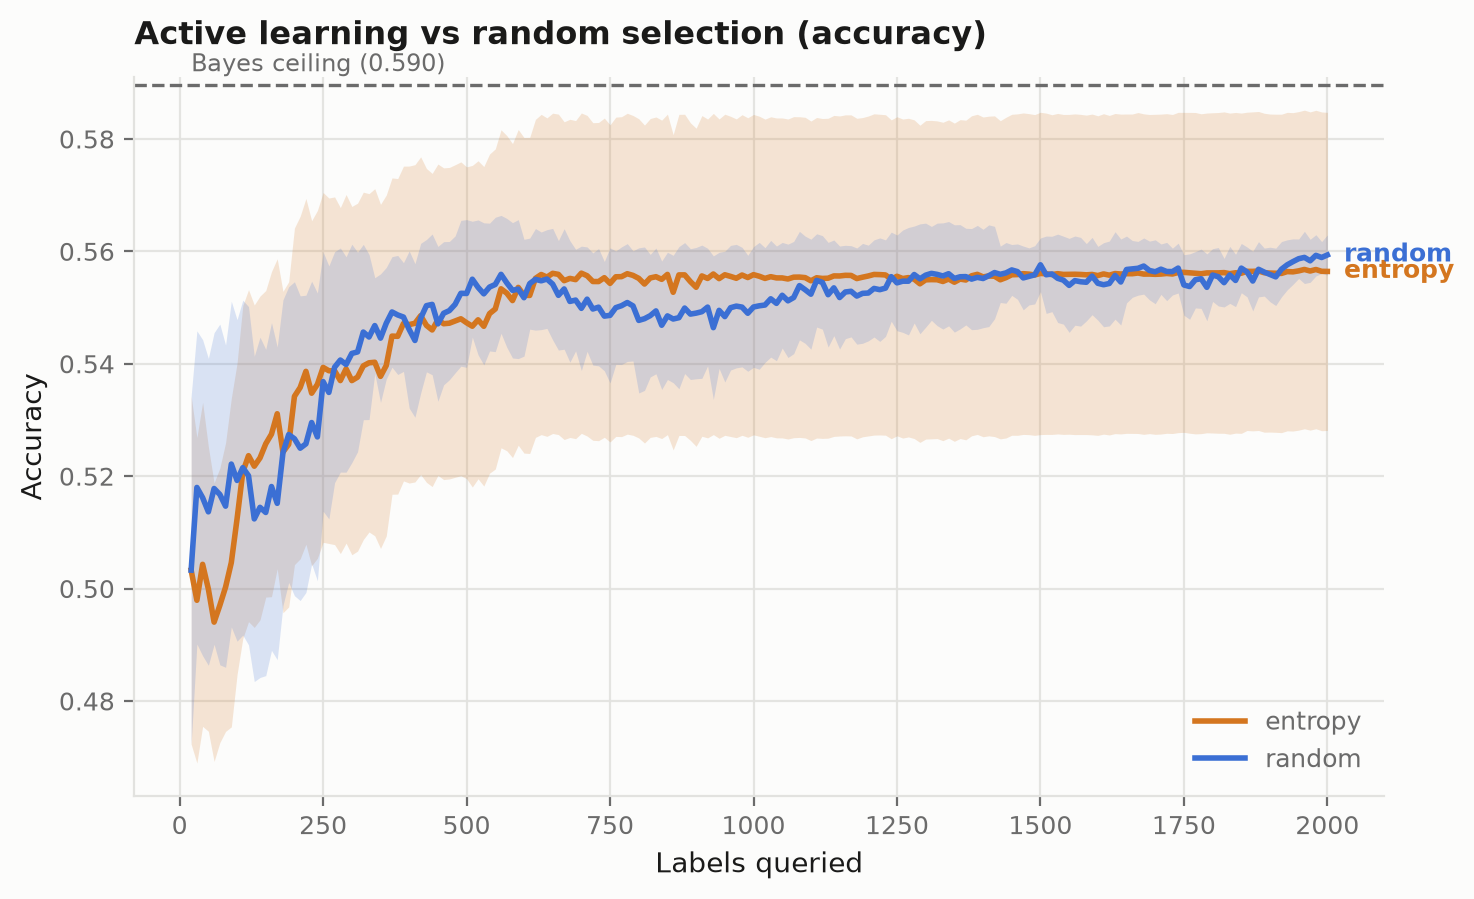

saved figure: /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/figures/learning_curve_accuracy.png


In [19]:
bath_curve_path = plots.plot_learning_curves(
    runs, bayes_ceiling=signal.estimated_max_accuracy
)
display(Image(filename=str(bath_curve_path), width=900))
print(f"saved figure: {bath_curve_path}")

#### Output explanation

**What the output is.** An embedded Bath accuracy learning-curve figure is shown and its saved repository path is printed.

**What the output means.** The random and entropy curves do not develop a stable active-learning separation, while entropy shows wider variation.

**Interpretation boundary.** The plotted accuracy view is secondary to balanced accuracy and applies only to the current Bath oracle and period.

### Code explanation: render Bath query allocation by zone

**Purpose.** Compare where random and entropy spend their label budgets.

**What the code does.** The plotting helper aggregates saved queries by room, saves the composition figure, embeds it, and prints its path.

**Why this step is justified.** Spatial allocation is direct evidence about query behaviour as a proxy.

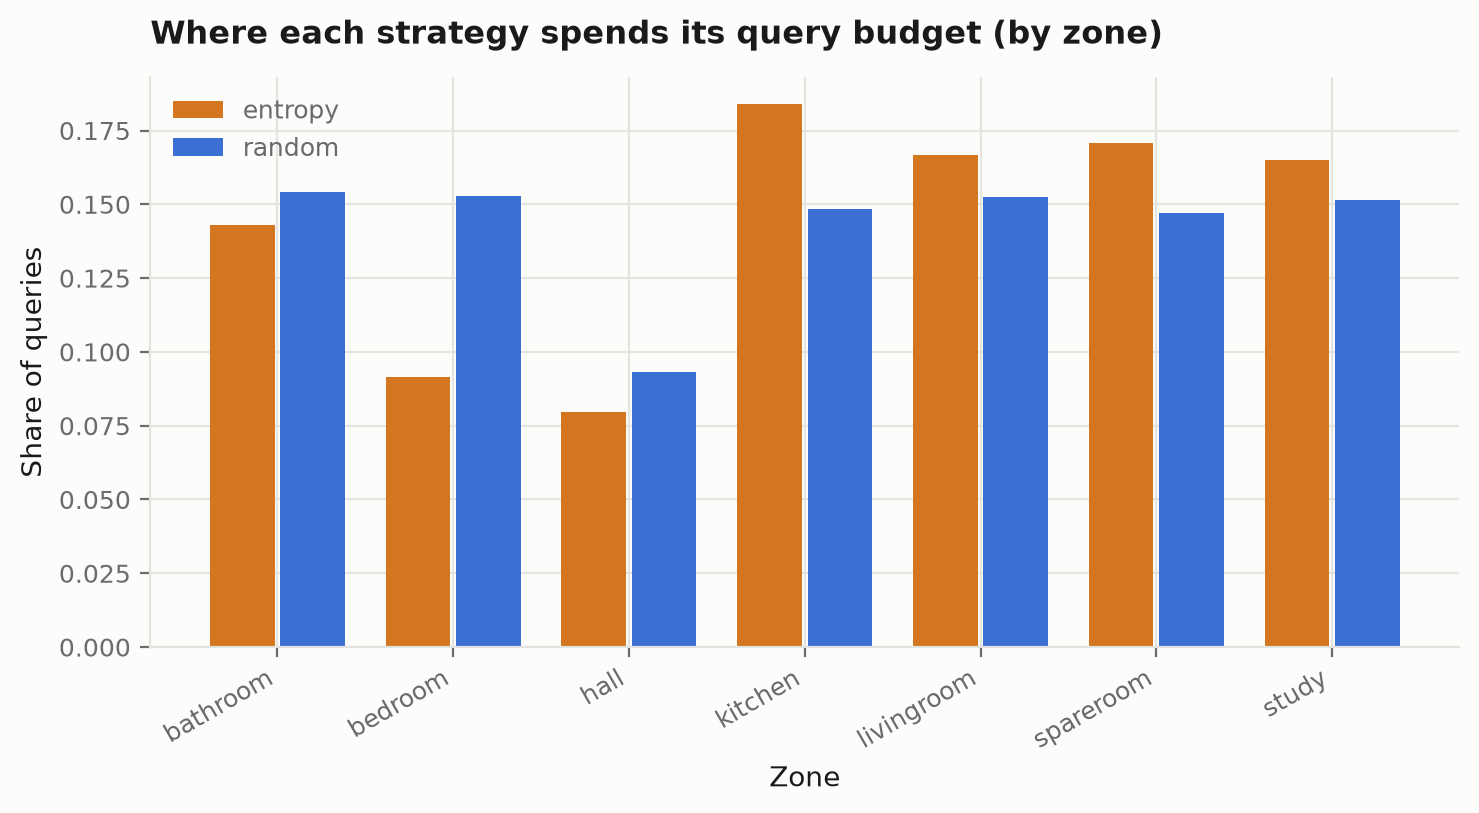

saved figure: /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/figures/query_composition_zone.png


In [20]:
bath_zone_path = plots.plot_query_composition(queries, by="zone")
display(Image(filename=str(bath_zone_path), width=900))
print(f"saved figure: {bath_zone_path}")

#### Output explanation

**What the output is.** An embedded zone-composition chart is produced and its saved path is printed.

**What the output means.** The two strategies allocate queries differently across rooms, motivating the later cross-seed stability analysis.

**Interpretation boundary.** A different allocation is not automatically a better or human-meaningful allocation.

### Code explanation: render queried conditions in T+RH space

**Purpose.** Show where selected observations lie relative to the available Bath pool.

**What the code does.** The helper plots query points against the pool in temperature-humidity space, saves the figure, embeds it, and prints its path.

**Why this step is justified.** This reveals environmental concentration that room counts alone cannot show.

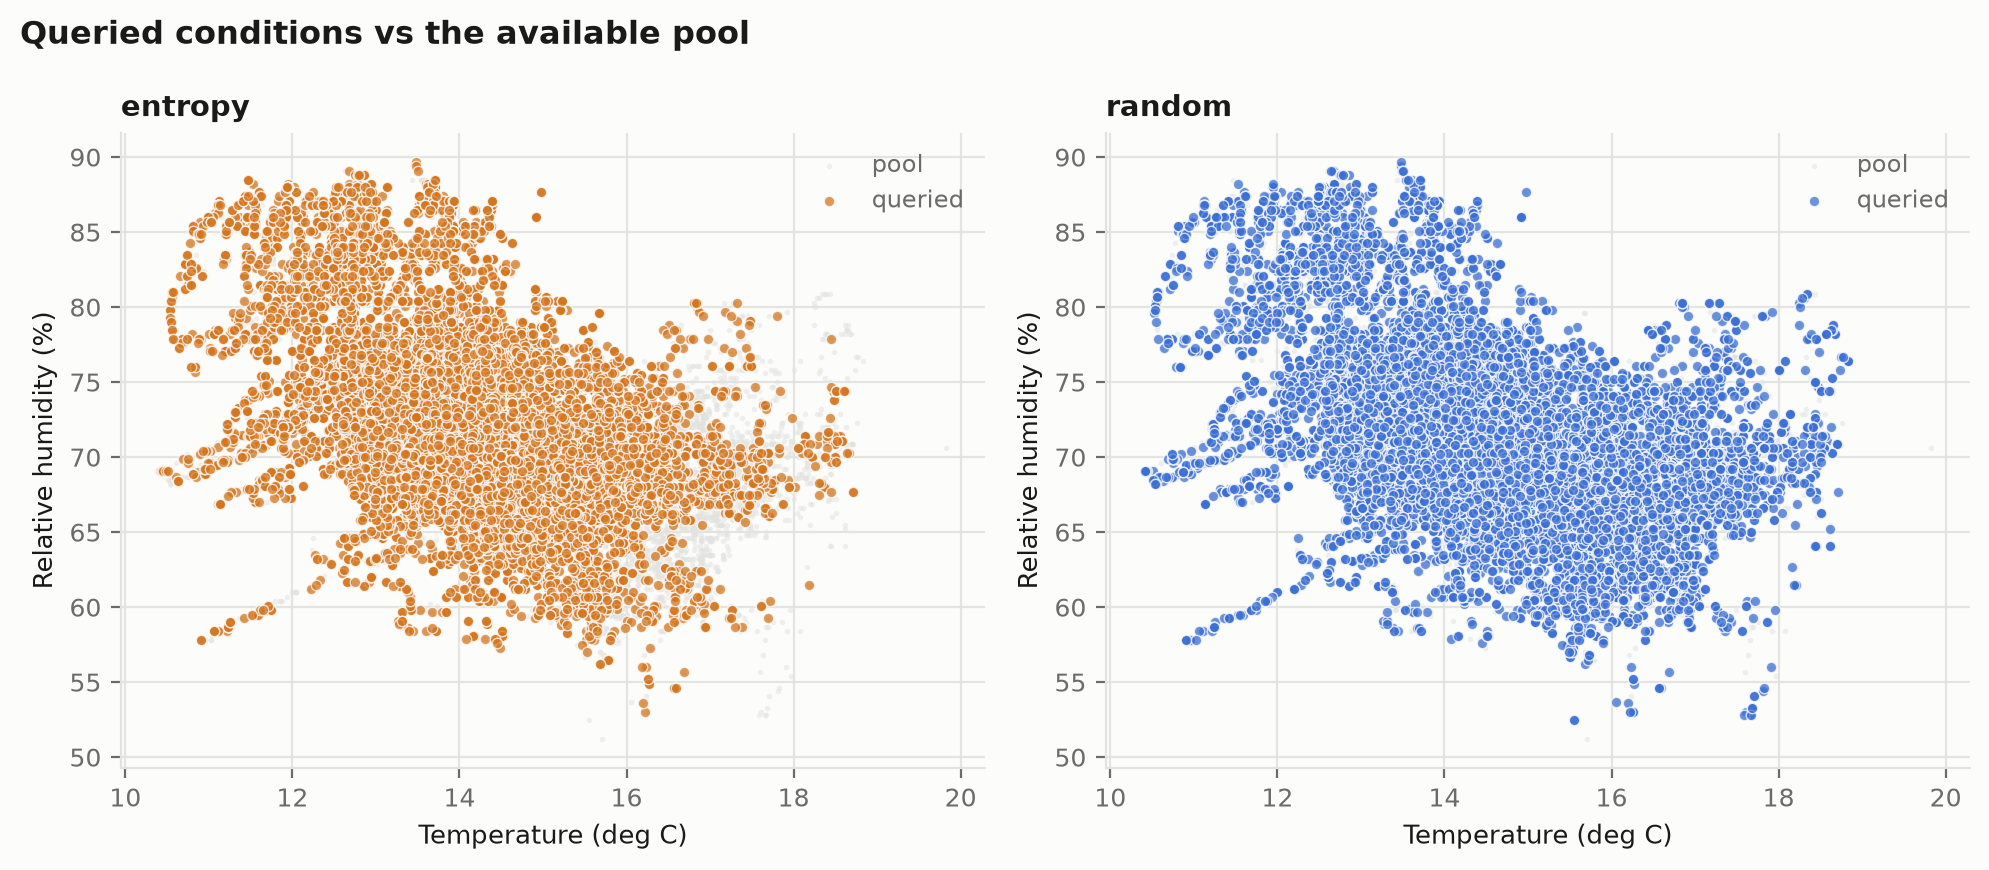

saved figure: /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/figures/query_scatter.png


In [21]:
bath_scatter_path = plots.plot_query_scatter(queries, pool=pool)
display(Image(filename=str(bath_scatter_path), width=900))
print(f"saved figure: {bath_scatter_path}")

#### Output explanation

**What the output is.** An embedded temperature-RH query scatter plot is shown with its saved path.

**What the output means.** The figure makes overlap and concentration of selected conditions inspectable against available data.

**Interpretation boundary.** The plot describes selected points; it does not reconstruct the model probability that caused each historical selection.

---
# 6b. Positive control — the same code on a different building

The Bath result on its own cannot distinguish "active learning does not work here" from "the
implementation is broken". A control settles it: run the **identical code, identical noise σ,
identical query strategies** on a second dataset.

LaSDPC is the Sprint-1 dataset. **Its labels are equally synthetic** — the same
`generate_labels(PMV + N(0, 1.0))` call. The only thing that differs is the building.


### Code explanation: compare Bath and LaSDPC label signal

**Purpose.** Use the same pre-flight diagnostic to separate a software issue from target learnability.

**What the code does.** The cell builds the LaSDPC synthetic target and displays side-by-side readings, temperature spread, PMV spread, noise, agreement, ceiling, baseline, headroom and learnable verdict.

**Why this step is justified.** The same code and noise on a second building provide a real-data control for the Bath diagnosis.

In [22]:
lasdpc = pipeline.build_labelled_dataset("lasdpc")
lasdpc_signal = validation.label_signal_report(lasdpc)

comparison = pd.DataFrame(
    {
        "Bath": {
            "readings": len(labelled),
            "temp std (degC)": labelled[schema.TEMPERATURE].std(),
            "PMV std (signal)": signal.pmv_std,
            "noise sigma": signal.noise_sigma,
            "signal-to-noise": signal.signal_to_noise,
            "PMV agreement": signal.pmv_agreement,
            "est. max accuracy": signal.estimated_max_accuracy,
            "majority baseline": signal.majority_class_rate,
            "headroom": signal.headroom,
            "learnable": signal.is_learnable,
        },
        "LaSDPC": {
            "readings": len(lasdpc),
            "temp std (degC)": lasdpc[schema.TEMPERATURE].std(),
            "PMV std (signal)": lasdpc_signal.pmv_std,
            "noise sigma": lasdpc_signal.noise_sigma,
            "signal-to-noise": lasdpc_signal.signal_to_noise,
            "PMV agreement": lasdpc_signal.pmv_agreement,
            "est. max accuracy": lasdpc_signal.estimated_max_accuracy,
            "majority baseline": lasdpc_signal.majority_class_rate,
            "headroom": lasdpc_signal.headroom,
            "learnable": lasdpc_signal.is_learnable,
        },
    }
)
comparison


,Bath,LaSDPC
readings,419602,1355
temp std (degC),1.973395,3.378587
PMV std (signal),0.268897,1.06832
noise sigma,1.0,1.0
signal-to-noise,0.268897,1.06832
PMV agreement,0.362544,0.365314
est. max accuracy,0.589582,0.872684
majority baseline,0.564938,0.667159
headroom,0.024645,0.205525
learnable,False,True


#### Output explanation

**What the output is.** Bath signal-to-noise is 0.269 with headroom 0.0246 and `learnable=False`; LaSDPC is 1.068 with headroom 0.2055 and `learnable=True`. Agreement remains similar at about 0.36.

**What the output means.** The label generator is comparably calibrated, but LaSDPC supplies much stronger PMV variation and theoretical raw-accuracy headroom.

**Interpretation boundary.** A favourable diagnostic does not guarantee a balanced entropy advantage; empirical matched results remain primary.

Both are calibrated identically against Cheung et al. (agreement 0.363 vs 0.365). The difference
is entirely in the **signal**: LaSDPC's building varies four times more in PMV terms.

The diagnostic called both **before either experiment was run**.


### Code explanation: load the LaSDPC raw-accuracy experiment

**Purpose.** Show the original second-building comparison using the same evaluation helpers.

**What the code does.** The cell reads frozen LaSDPC runs and prints final raw strategy statistics and raw-accuracy label efficiency.

**Why this step is justified.** This provides historical continuity and illustrates why raw and balanced interpretations must be separated.

In [23]:
lasdpc_runs = pd.read_csv(config.RESULTS_DIR / "lasdpc_runs.csv")

print("LaSDPC - random vs entropy, 10 seeds")
print(analysis.strategy_comparison(lasdpc_runs).round(4).to_string(index=False))
print()
print("Label efficiency:")
print(analysis.label_efficiency(lasdpc_runs).to_string(index=False))


LaSDPC - random vs entropy, 10 seeds
strategy  accuracy    std  count  n_labels  delta_vs_random  p_value_vs_random
 entropy    0.7356 0.0233     10       400           0.0189             0.0398
  random    0.7167 0.0124     10       400           0.0000                NaN

Label efficiency:
strategy  target_metric  labels_to_target  reached_target  label_saving
 entropy       0.716708                30            True        0.8125
  random       0.716708               160            True        0.0000


#### Output explanation

**What the output is.** Entropy raw accuracy is 0.7356 versus 0.7167 random, with the original comparison p=0.0398; entropy reaches the raw target at 30 versus 160 labels, an 81.25% saving.

**What the output means.** Under raw accuracy, LaSDPC appears to be a positive real-data control.

**Interpretation boundary.** The later matched balanced result is -0.0019 with p=0.850; therefore this raw gain is secondary and cannot prove class-balanced AL success.

### Code explanation: render the LaSDPC learning curve

**Purpose.** Visualise the raw-accuracy separation that motivated the original positive-control interpretation.

**What the code does.** The plotting helper uses frozen LaSDPC runs and its conditional ceiling, saves and embeds the curve, then prints its path.

**Why this step is justified.** Displaying both buildings helps distinguish different observed learning behaviour under the same code.

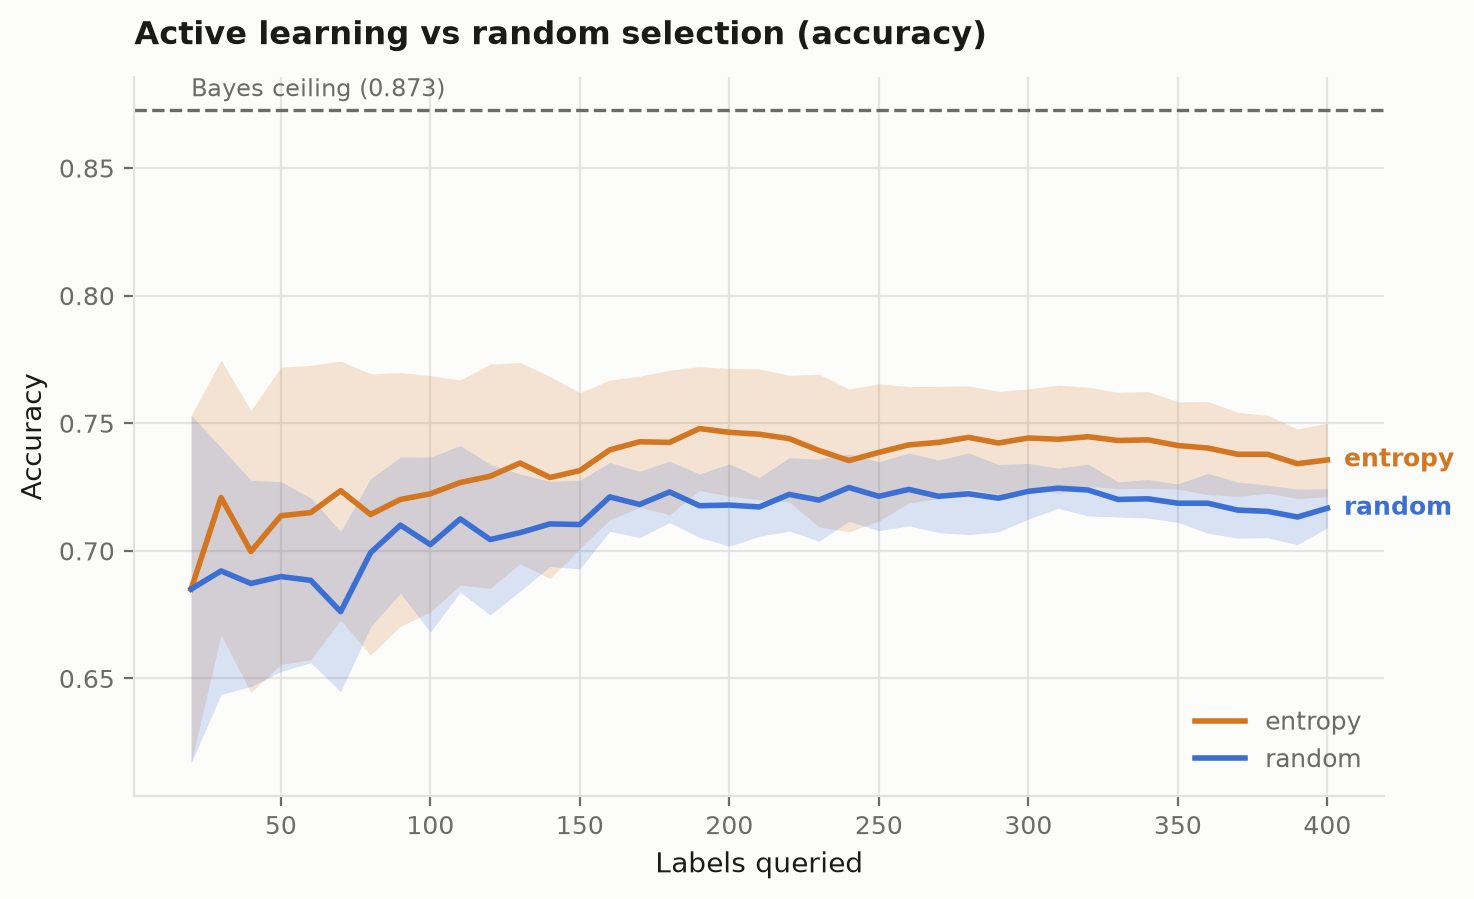

saved figure: /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/figures/lasdpc_learning_curve.png


In [24]:
lasdpc_curve_path = plots.plot_learning_curves(
    lasdpc_runs,
    bayes_ceiling=lasdpc_signal.estimated_max_accuracy,
    path=config.FIGURES_DIR / "lasdpc_learning_curve.png",
)
display(Image(filename=str(lasdpc_curve_path), width=900))
print(f"saved figure: {lasdpc_curve_path}")

#### Output explanation

**What the output is.** An embedded LaSDPC learning-curve figure is displayed and its saved path is printed.

**What the output means.** The raw-accuracy entropy curve separates earlier than random, unlike the Bath raw curves.

**Interpretation boundary.** This remains a class-imbalance-sensitive view; the primary balanced table below supersedes it for the final claim.

## What the raw-accuracy comparison establishes — secondary view

On LaSDPC the same loop shows a raw-accuracy advantage and reaches random's final raw accuracy
with roughly **one fifth of the labels**. The later balanced-accuracy comparison does not retain
that advantage (entropy 0.5782 vs random 0.5801, paired p=0.850), so this is a secondary
class-imbalance-sensitive observation rather than proof of empirical AL success.

The controlled deterministic benchmark in `three_stage_active_learning_comparison.ipynb` shows
that the implementation works. Bath's null reflects the interaction between its thermal range,
the clothing treatment and the noisy oracle, not a software defect. Compare the raw-accuracy
learning-curve figures: LaSDPC separates, while Bath's two lines
are indistinguishable — and entropy's confidence band on Bath is visibly wider, because with no
signal to follow, "select the most uncertain reading" is selecting noise.


---
# 6c. Primary class-balanced three-stage assessment

The earlier raw-accuracy tables are retained as secondary diagnostics. Balanced accuracy is primary
because both real-data targets are class-imbalanced.

The three evidence stages answer different questions:

1. **Controlled deterministic three-class:** can the implementation learn an informative boundary?
2. **LaSDPC noisy oracle:** does that benefit transfer to a second real sensor distribution?
3. **Bath noisy oracle:** does it transfer to the target heritage-building period and assumptions?

The controlled benchmark is deliberately learnable. It is not evidence that Bath experienced all
three conditions.


### Code explanation: present the primary balanced three-stage result

**Purpose.** Consolidate controlled capability and both real-data evaluations using the class-balanced metric.

**What the code does.** The cell creates a presentation table from the frozen matched-seed results, including means, difference, paired p-value and labels needed to reach the random target.

**Why this step is justified.** A single primary table prevents the secondary LaSDPC raw gain from being mistaken for the dissertation conclusion.

In [25]:
# Frozen matched-seed values from three_stage_active_learning_comparison.ipynb.
primary_balanced = pd.DataFrame([
    {
        "stage": "Controlled deterministic three-class",
        "random balanced accuracy": 0.9826,
        "entropy balanced accuracy": 0.9925,
        "entropy - random": 0.0099,
        "paired p-value": 1.0928e-05,
        "entropy labels to random target": 120,
        "random labels to target": 250,
    },
    {
        "stage": "LaSDPC noisy oracle",
        "random balanced accuracy": 0.5801,
        "entropy balanced accuracy": 0.5782,
        "entropy - random": -0.0019,
        "paired p-value": 0.8505,
        "entropy labels to random target": "Not reached",
        "random labels to target": 220,
    },
    {
        "stage": "Bath noisy oracle",
        "random balanced accuracy": 0.5087,
        "entropy balanced accuracy": 0.5043,
        "entropy - random": -0.0044,
        "paired p-value": 0.0567,
        "entropy labels to random target": "Not reached",
        "random labels to target": 1950,
    },
])
primary_balanced

,stage,random balanced accuracy,entropy balanced accuracy,entropy - random,paired p-value,entropy labels to random target,random labels to target
0,Controlled deterministic three-class,0.9826,0.9925,0.0099,0.000011,120,250
1,LaSDPC noisy oracle,0.5801,0.5782,-0.0019,0.850500,Not reached,220
2,Bath noisy oracle,0.5087,0.5043,-0.0044,0.056700,Not reached,1950


#### Output explanation

**What the output is.** Controlled entropy is 0.9925 versus 0.9826 random, difference +0.0099, p=0.0000109 and 120 versus 250 labels. LaSDPC and Bath differences are -0.0019 and -0.0044, and neither reaches the random target.

**What the output means.** The implementation works and saves 52% of labels when a learnable three-class boundary exists, but neither current noisy real-data target demonstrates a balanced entropy advantage.

**Interpretation boundary.** Controlled capability does not prove Bath effectiveness; real-data nulls are retained rather than tuned away.

---
# 6d. Query behaviour and retrospective SHAP evidence

The research question concerns query behaviour as a potential proxy, so accuracy alone is
insufficient. The saved query logs are analysed for environmental conditions, class composition,
zone/month concentration and stability across seeds.

SHAP has a stricter boundary. The exports do not contain the initial seed rows, selection-time class
probabilities or a historical model snapshot for every query. The displayed SHAP examples therefore
come from seed-42 retrospective reference models fitted only to exported queried labels. They are
illustrative audit evidence—not reconstructions of why the historical loop selected a row at that
instant, and not causal feature effects.


### Code explanation: summarise query behaviour across seeds

**Purpose.** Measure environmental composition and allocation stability for both datasets and strategies.

**What the code does.** The cell reads the generated saved-query summary and selects counts, mean T/RH, trigger share, class shares and zone/month TVD.

**Why this step is justified.** The formal proxy question requires repeated query-behaviour evidence, not one seed's room counts.

In [26]:
query_summary = pd.read_csv(config.RESULTS_DIR / "query_behaviour_summary.csv")
query_summary[[
    "dataset", "strategy", "queries", "temperature_mean", "rh_mean",
    "triggered_share", "too_cool_share", "comfortable_share", "too_warm_share",
    "zone_seed_tvd", "month_seed_tvd",
]].round(4)

,dataset,strategy,queries,temperature_mean,rh_mean,triggered_share,too_cool_share,comfortable_share,too_warm_share,zone_seed_tvd,month_seed_tvd
0,Bath,entropy,19800,14.1023,72.4132,0.9995,0.4695,0.5305,0.0000,0.0887,0.0787
1,Bath,random,19800,14.4300,71.6951,0.9995,0.4403,0.5597,0.0000,0.0333,0.0266
2,LaSDPC,entropy,3800,23.1594,69.6817,0.7674,0.2013,0.7126,0.0861,0.2180,0.0000
3,LaSDPC,random,3800,22.3530,68.3704,0.7234,0.2666,0.6679,0.0655,0.0373,0.0000


#### Output explanation

**What the output is.** Bath entropy queries average 14.1023 degrees C and 72.4132% RH versus random 14.4300 and 71.6951; Bath zone TVD is 0.0887 versus 0.0333. LaSDPC entropy zone TVD is 0.2180 versus 0.0373. Bath trigger share is 0.9995 for both.

**What the output means.** Entropy selects a measurably different and less seed-stable allocation, while the Bath domain trigger cannot discriminate the arms.

**Interpretation boundary.** Different query composition is descriptive proxy evidence; it does not establish that real occupants would find the questions useful.

### Code explanation: display cross-seed query figures

**Purpose.** Make the Bath and LaSDPC condition/zone comparisons visually inspectable.

**What the code does.** The cell embeds four generated PNGs covering query conditions and zone shares for both datasets.

**Why this step is justified.** Figures expose distribution shape and between-strategy concentration that summary means compress.

**Bath Query Conditions Balanced Review**

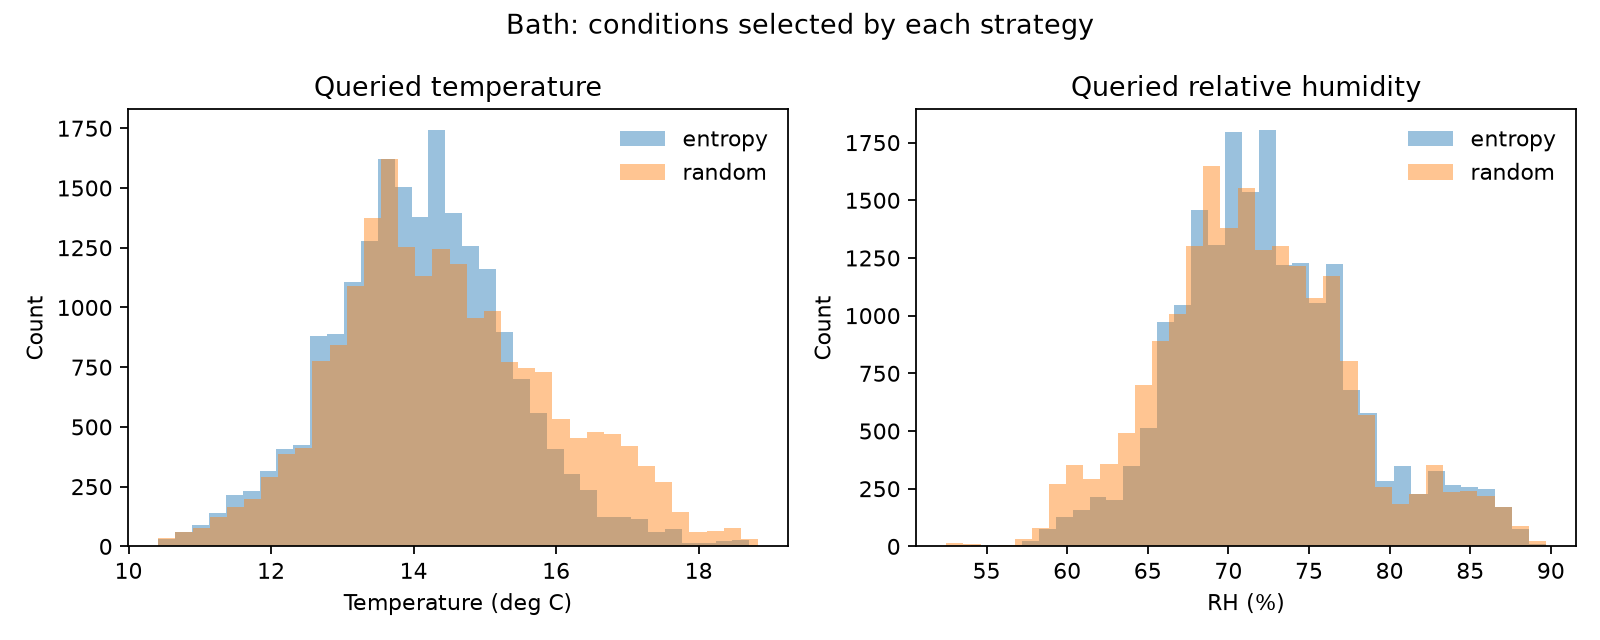

**Bath Query Zone Share Balanced Review**

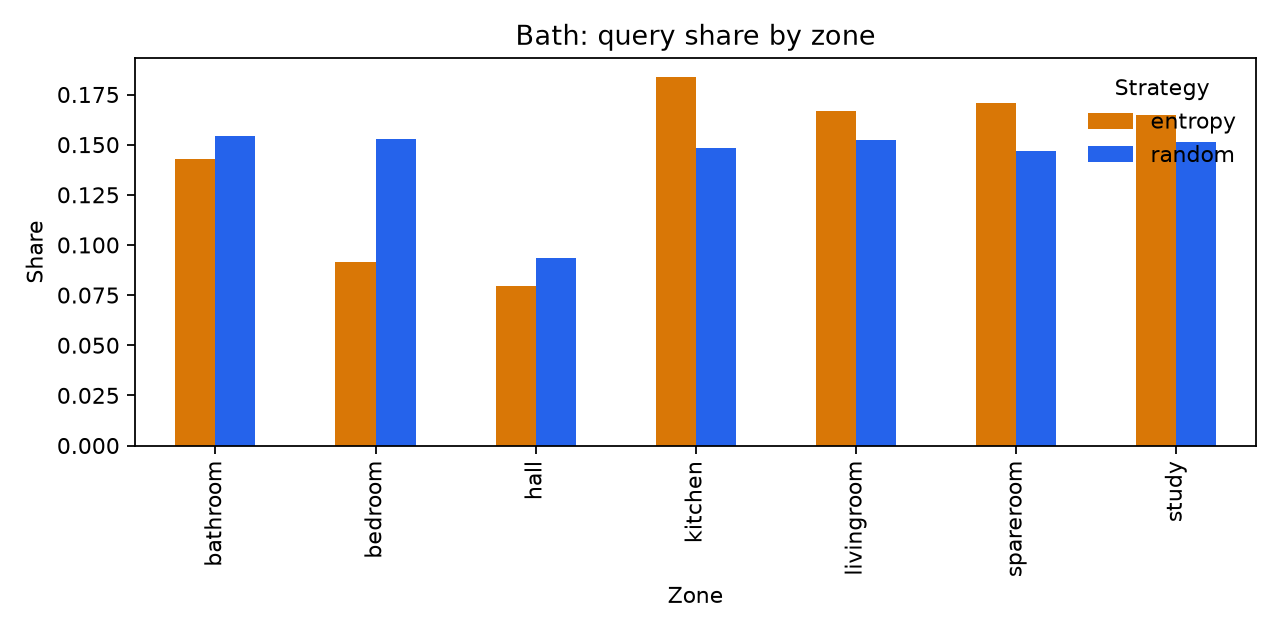

**Lasdpc Query Conditions Balanced Review**

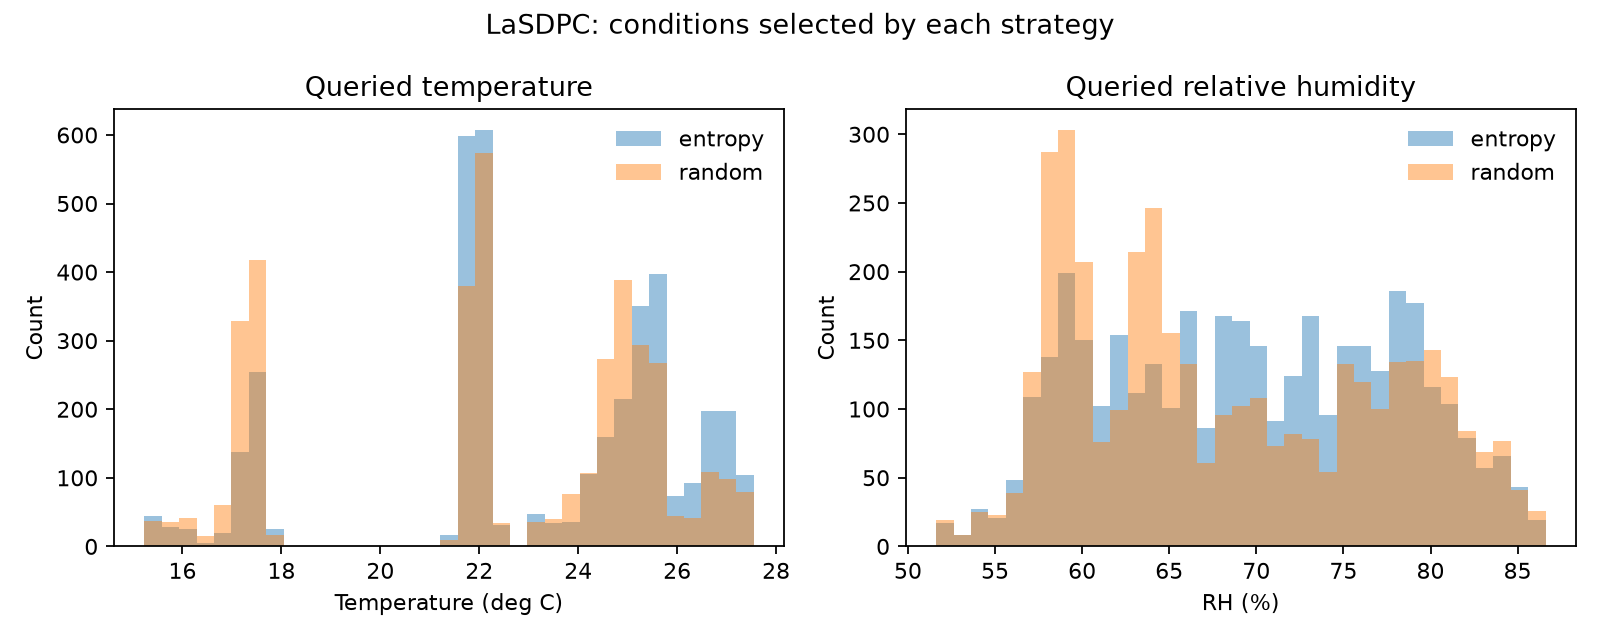

**Lasdpc Query Zone Share Balanced Review**

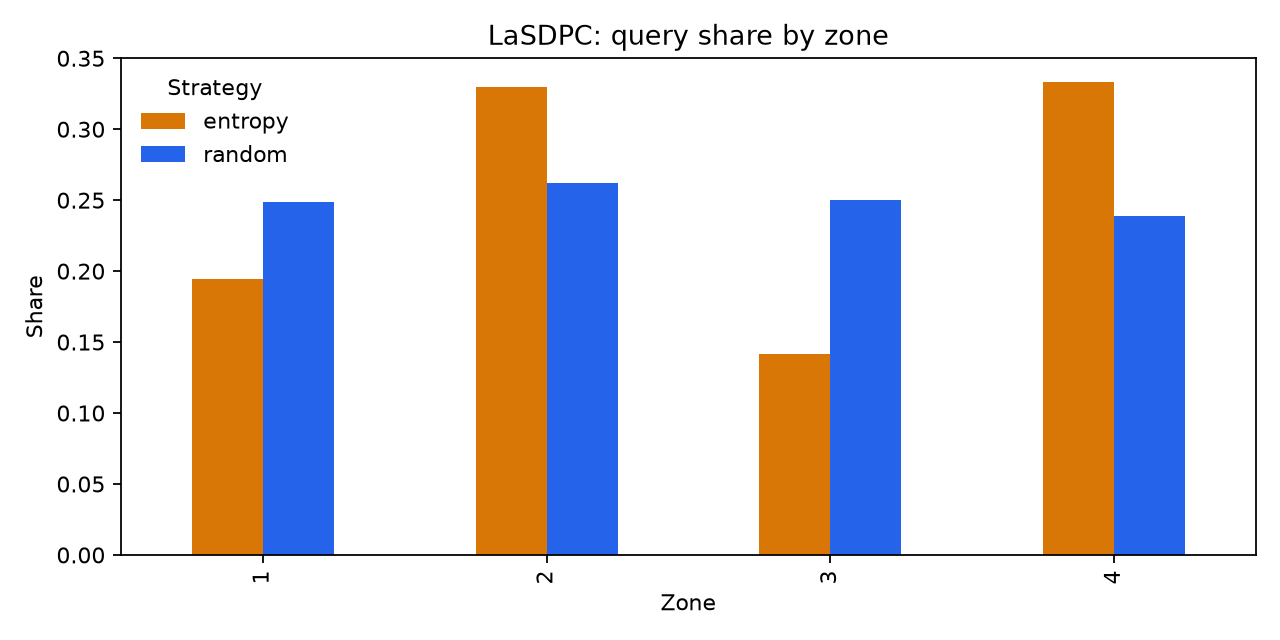

In [27]:
query_figure_paths = [
    config.FIGURES_DIR / "bath_query_conditions_balanced_review.png",
    config.FIGURES_DIR / "bath_query_zone_share_balanced_review.png",
    config.FIGURES_DIR / "lasdpc_query_conditions_balanced_review.png",
    config.FIGURES_DIR / "lasdpc_query_zone_share_balanced_review.png",
]
for figure_path in query_figure_paths:
    display(Markdown(f"**{figure_path.stem.replace('_', ' ').title()}**"))
    display(Image(filename=str(figure_path), width=900))

#### Output explanation

**What the output is.** Four labelled query-evidence figures are rendered for Bath and LaSDPC.

**What the output means.** They visually support the measured condition differences and strategy allocation patterns.

**Interpretation boundary.** The figures come from saved query logs and do not contain selection-time model snapshots.

### Code explanation: display retrospective SHAP audit examples

**Purpose.** Show whether temperature or RH dominates representative fitted predictions.

**What the code does.** The cell loads generated seed-42 examples, renames the prediction field accurately, and displays early/middle/late rows for both datasets and strategies.

**Why this step is justified.** SHAP supports auditability only when the reference-model limitation is explicit.

In [28]:
shap_examples = pd.read_csv(config.RESULTS_DIR / "query_shap_examples.csv").rename(
    columns={"final_model_prediction": "reference_model_prediction"}
)
shap_examples[[
    "dataset", "strategy", "phase", "temperature", "relative_humidity",
    "observed_label", "reference_model_prediction", "temperature_shap",
    "rh_shap", "dominant_feature",
]].round(4)

,dataset,strategy,phase,temperature,relative_humidity,observed_label,reference_model_prediction,temperature_shap,rh_shap,dominant_feature
0,Bath,entropy,early,17.3170,79.1000,comfortable,comfortable,0.4364,0.0604,temperature
1,Bath,entropy,middle,14.9340,72.7000,comfortable,comfortable,0.0231,0.1862,relative_humidity
2,Bath,entropy,late,13.9220,86.8000,too_cool,too_cool,0.1136,0.2421,relative_humidity
3,Bath,random,early,16.1980,74.1000,comfortable,comfortable,0.1822,0.1685,temperature
4,Bath,random,middle,15.4060,72.4000,comfortable,comfortable,0.3337,0.1019,temperature
5,Bath,random,late,13.8640,73.0000,comfortable,comfortable,0.0924,0.0583,temperature
6,LaSDPC,entropy,early,27.0238,57.1414,comfortable,comfortable,0.1639,0.4031,relative_humidity
7,LaSDPC,entropy,middle,26.6810,69.2700,comfortable,too_warm,0.1489,0.0400,temperature
8,LaSDPC,entropy,late,22.1280,84.9520,comfortable,comfortable,0.1053,0.5217,relative_humidity
9,LaSDPC,random,early,17.1368,57.1867,comfortable,too_cool,0.2457,0.0216,temperature


#### Output explanation

**What the output is.** A twelve-row table shows conditions, observed labels, reference predictions, temperature/RH SHAP magnitudes and the dominant feature.

**What the output means.** Both permitted features can dominate depending on the selected case, providing inspectable examples of fitted model behaviour.

**Interpretation boundary.** These models use exported queried labels only; the values are not historical query causes or causal comfort effects.

---
# 7. Validation

Accuracy alone would be misleading here. Two failure modes it cannot detect:

1. A model that simply predicts the majority class every time.
2. A model that looks adequate overall while performing poorly on the minority class.

So the report includes per-class precision and recall, the majority-class baseline, a confidence
interval on accuracy, and a calibration score.

### Code explanation: validate the Bath static baseline

**Purpose.** Evaluate held-out predictive performance with class-aware and calibration statistics.

**What the code does.** The cell trains the shared static Random Forest on the pool and prints sample size, accuracy interval, majority baseline, balanced accuracy, macro-F1, conditional ceiling ratio, Brier score and agreement.

**Why this step is justified.** A static baseline reveals whether poor active querying reflects a broader weak-target problem.

In [29]:
final_model = al.train_static_baseline(pool)
report = validation.validate(final_model, test_set)

for line in report.summary_lines():
    print(" ", line)

  n (test)              25000
  accuracy              0.5596  95% CI [0.5534, 0.5657]
  majority-class rate   0.5762  (trivial baseline)
  balanced accuracy     0.5096
  macro F1              0.4729
  est. max accuracy     0.5775  (under the assumed label-generation + noise process, given these features)
  ratio to est. max     0.969
  Brier score           0.3201  (lower is better-calibrated)
  PMV agreement         0.368  (expect ~0.33, Cheung 2019)


#### Output explanation

**What the output is.** Accuracy is 0.5596, below the 0.5762 test majority rate; balanced accuracy is 0.5096, macro-F1 0.4729 and Brier score 0.3201.

**What the output means.** The model is near chance on class-balanced discrimination despite approaching the conditional raw ceiling, confirming very limited useful target structure.

**Interpretation boundary.** A high ratio to the conditional ceiling is not strong real-world accuracy when the ceiling itself is close to a trivial baseline.

### Code explanation: inspect per-class errors

**Purpose.** Identify which class is hidden by the aggregate accuracy.

**What the code does.** The cell prints precision, recall and F1 for each class and a confusion matrix with actual classes as rows.

**Why this step is justified.** Class imbalance can make a majority-heavy model appear adequate while failing the minority class.

In [30]:
print("per-class performance")
print(report.per_class.round(4).to_string(index=False))

print("\nconfusion matrix (rows = actual, columns = predicted)")
print(report.confusion.to_string())

per-class performance
      class  precision  recall     f1  support
comfortable     0.5819  0.8376 0.6867    14405
   too_cool     0.4513  0.1817 0.2591    10595

confusion matrix (rows = actual, columns = predicted)
predicted    comfortable  too_cool
actual                            
comfortable        12065      2340
too_cool            8670      1925


#### Output explanation

**What the output is.** Comfortable recall is 0.8376, but too-cool recall is only 0.1817; 8,670 too-cool cases are predicted comfortable.

**What the output means.** The model largely favours the majority comfortable class, explaining why raw accuracy overstates discrimination.

**Interpretation boundary.** This is why balanced accuracy and macro-F1 are primary for the dissertation conclusion.

### Code explanation: audit probability calibration

**Purpose.** Check whether predicted probabilities correspond to observed class frequencies.

**What the code does.** The cell bins predicted too-cool probabilities and compares each bin's mean prediction with observed frequency and count.

**Why this step is justified.** Entropy selection ranks probability distributions, so distorted probabilities can create distorted query priorities.

In [31]:
# Calibration matters mechanically: entropy sampling ranks readings by predicted
# probability, so a miscalibrated model would be selecting on a distorted signal.
validation.calibration_curve(final_model, test_set).round(4)

,bin,bin_lower,bin_upper,mean_predicted,observed_frequency,count
0,0,0.0,0.1,0.0418,0.3919,8822
1,1,0.1,0.2,0.1428,0.4229,4845
2,2,0.2,0.3,0.2479,0.4438,3378
3,3,0.3,0.4,0.3472,0.4441,1975
4,4,0.4,0.5,0.4464,0.4655,1637
5,5,0.5,0.6,0.5483,0.4421,1425
6,6,0.6,0.7,0.6520,0.4728,1214
7,7,0.7,0.8,0.7467,0.4510,980
8,8,0.8,0.9,0.8429,0.4362,486
9,9,0.9,1.0,0.9343,0.3908,238


#### Output explanation

**What the output is.** Observed too-cool frequency remains roughly 0.39-0.47 across bins even when mean predicted probability ranges from 0.04 to 0.93.

**What the output means.** The uncalibrated model is severely overconfident and its probability ranking does not track actual frequency reliably.

**Interpretation boundary.** Calibration failure helps explain unstable entropy querying; it does not prove every Random Forest is unsuitable.

---
# 8. Robustness checks

Two studies designed to attack the result rather than support it.

## 8.1 Is the model learning the label-generation rule?

Clothing is derived from outdoor temperature, and clothing feeds the PMV that generates the
label. If the model could see outdoor temperature, it could partly learn the labelling rule
rather than a comfort relationship.

The model receives **only indoor temperature and humidity** — outdoor temperature is never a
feature. But indoor and outdoor temperature correlate, so seasonal information reaches the model
indirectly. This ablation measures how much:

- `month_only` — sees nothing but the calendar month. Whatever it achieves is attributable to
  seasonal structure, not comfort physics.
- `full` — the real model.

If `month_only` approaches `full`, the model is largely reproducing the labelling rule.

### Code explanation: test seasonal circularity with feature ablations

**Purpose.** Check whether the model is mainly reproducing the clothing/season labelling rule.

**What the code does.** Across three seeds, the robustness helper compares full T+RH, temperature-only, humidity-only and month-only feature sets against the majority baseline.

**Why this step is justified.** Outdoor context is excluded from the model, but correlated indoor seasonality could still leak the oracle structure indirectly.

In [32]:
circularity = robustness.circularity_check(labelled, pool_size=5_000, seeds=(42, 43, 44))
robustness.summarise_circularity(circularity).round(4)

,arm,features,mean,std,count,majority_class_rate,lift_over_majority,share_of_full_lift
0,temperature_only,temperature,0.5553,0.0028,3,0.5762,-0.0209,0.8730
1,full,"temperature, relative_humidity",0.5523,0.0070,3,0.5762,-0.0239,1.0000
2,humidity_only,relative_humidity,0.5060,0.0015,3,0.5762,-0.0702,2.9315
3,month_only,month,0.4238,0.0000,3,0.5762,-0.1524,6.3677


#### Output explanation

**What the output is.** All ablations have negative lift over the 0.5762 majority baseline; temperature-only is closest at 0.5553, full T+RH is 0.5523 and month-only is 0.4238.

**What the output means.** The model is not gaining its apparent performance by simply reading calendar month; no tested feature set beats the trivial majority rule.

**Interpretation boundary.** Negative lift under this split reflects both weak labels and temporal shift; the unusual share-of-lift values are not substantive when the denominator is negative.

## 8.2 Does the conclusion depend on the clothing rule?

The clothing model is a defensible assumption, not a measurement. A result that held only for
one particular rule would be an artefact of that choice. Here the labels are regenerated under
several clothing assumptions — fixed values, and outdoor-driven rules of differing sensitivity.

⚠️ This cell takes several minutes.

### Code explanation: test clothing-rule sensitivity

**Purpose.** Measure whether performance and class balance depend on one arbitrary clothing equation.

**What the code does.** The helper regenerates targets for fixed and outdoor-responsive clothing variants across two seeds and reports class share, mean clo, accuracy, conditional ceiling and degeneracy.

**Why this step is justified.** Clothing is assumed rather than observed, so a conclusion that disappears under plausible alternatives must be disclosed.

In [33]:
sensitivity_clo = robustness.clothing_sensitivity(
    with_clo, pool_size=5_000, seeds=(42, 43)
)
sensitivity_clo.round(4)

,variant,description,seed,n_classes,too_cool_share,mean_clo,accuracy,estimated_max_accuracy,ceiling_ratio,degenerate
0,adopted,"Outdoor-driven, adopted parameters (DD-017)",42,2,0.4351,0.9766,0.5550,0.5775,0.9609,False
1,adopted,"Outdoor-driven, adopted parameters (DD-017)",43,2,0.4351,0.9766,0.5575,0.5775,0.9653,False
2,fixed_1.0,"Fixed 1.0 clo — a business suit, ISO 7730's wi...",42,2,0.4193,1.0000,0.6702,0.7367,0.9098,False
3,fixed_1.0,"Fixed 1.0 clo — a business suit, ISO 7730's wi...",43,2,0.4193,1.0000,0.6804,0.7367,0.9235,False
4,fixed_1.25,Fixed 1.25 clo — suit plus a jumper,42,2,0.2606,1.2500,0.7444,0.8484,0.8774,False
5,fixed_1.25,Fixed 1.25 clo — suit plus a jumper,43,2,0.2606,1.2500,0.7682,0.8484,0.9055,False
6,shallow_slope,Outdoor-driven but half as responsive to outdo...,42,2,0.3305,1.1133,0.6752,0.7510,0.8991,False
7,shallow_slope,Outdoor-driven but half as responsive to outdo...,43,2,0.3305,1.1133,0.6934,0.7510,0.9232,False
8,steep_slope,Outdoor-driven but twice as responsive,42,2,0.6103,0.7973,0.5018,0.6508,0.7710,False
9,steep_slope,Outdoor-driven but twice as responsive,43,2,0.6103,0.7973,0.5038,0.6508,0.7741,False


#### Output explanation

**What the output is.** All tested variants remain two-class but yield materially different too-cool shares, ceilings and accuracies; adopted-clothing accuracy is about 0.556, while fixed 1.25 reaches roughly 0.74-0.77 with a different target.

**What the output means.** The clothing assumption strongly affects target difficulty. The adopted null is therefore conditional, and the larger Bath-LaSDPC signal gap is partly created by modelling choices.

**Interpretation boundary.** Higher accuracy under another clothing rule does not make that rule more valid. Calibration must be selected scientifically, not by the preferred score.

---
# 8b. Should the system act at all? (selective prediction)

Forcing a prediction on every reading is the wrong evaluation for a heritage system. Intervention
is only warranted when discomfort is *confidently* identified — the Burra Charter
minimum-intervention principle. Standard accuracy penalises that behaviour, because it grades the
model on readings where the label is a coin flip.

Instead: at each confidence threshold, how often would the system **act** (coverage), and how often
is it **right** when it does (precision)?


### Code explanation: measure uncalibrated risk-coverage

**Purpose.** Test whether abstaining on low-confidence cases leaves a reliable actionable subset.

**What the code does.** For thresholds 0.50-0.95, the cell reports acted cases, coverage, precision, recall, base rate and lift.

**Why this step is justified.** Minimum intervention requires acting rarely and accurately rather than forcing a prediction on every reading.

In [34]:
rc = validation.risk_coverage(final_model, test_set)
print("UNCALIBRATED model")
print(rc.round(4).to_string(index=False))


UNCALIBRATED model
 threshold  n_acted  coverage  precision  recall  base_rate  lift_over_base
      0.50     4343    0.1737     0.4492  0.1841     0.4238          0.0254
      0.60     2968    0.1187     0.4532  0.1269     0.4238          0.0294
      0.70     1742    0.0697     0.4397  0.0723     0.4238          0.0159
      0.80      724    0.0290     0.4213  0.0288     0.4238         -0.0025
      0.90      238    0.0095     0.3908  0.0088     0.4238         -0.0330
      0.95       75    0.0030     0.3733  0.0026     0.4238         -0.0505


#### Output explanation

**What the output is.** Coverage falls from 17.37% at threshold 0.50 to 0.30% at 0.95, but precision also falls from 0.4492 to 0.3733 and becomes worse than base rate above 0.80.

**What the output means.** The uncalibrated model is least trustworthy where it appears most confident, consistent with memorised noise.

**Interpretation boundary.** Confidence thresholds are unusable until probability calibration is addressed.

**Precision falls as confidence rises.** A well-behaved model shows the opposite. Here the model
is least accurate exactly where it is most confident — dropping below the base rate above 0.80.
Its high-confidence predictions are memorised noise.

Now the same measurement on a model whose probabilities have been calibrated:


### Code explanation: calibrate probabilities and re-test actionability

**Purpose.** Determine whether honest probabilities identify any sufficiently confident too-cool cases.

**What the code does.** The cell fits an isotonic-calibrated Random Forest with three-fold calibration, predicts held-out too-cool probabilities and reports maximum probability and threshold coverage.

**Why this step is justified.** A heritage decision-support PoC should abstain when evidence is weak rather than turn overconfidence into intervention.

In [35]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

FEAT = ["temperature", "relative_humidity"]
y_pool = (pool[sl.COMFORT_CLASS] == config.COMFORT_CLASS_TOO_COOL).astype(int)
y_test = (test_set[sl.COMFORT_CLASS] == config.COMFORT_CLASS_TOO_COOL).astype(int).to_numpy()

calibrated = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=config.N_ESTIMATORS, random_state=config.RANDOM_SEED),
    method="isotonic",
    cv=3,
).fit(pool[FEAT], y_pool)

probability = calibrated.predict_proba(test_set[FEAT])[:, 1]
print(f"base rate            {y_test.mean():.4f}")
print(f"max P(too_cool)      {probability.max():.4f}")
print()
for threshold in (0.5, 0.6, 0.7, 0.8):
    print(f"  coverage at P>={threshold}: {(probability >= threshold).mean():.4f}")


base rate            0.4238
max P(too_cool)      0.4784

  coverage at P>=0.5: 0.0000
  coverage at P>=0.6: 0.0000
  coverage at P>=0.7: 0.0000
  coverage at P>=0.8: 0.0000


#### Output explanation

**What the output is.** The test base rate is 0.4238, maximum calibrated P(too_cool) is 0.4784, and coverage is zero at every threshold from 0.50 to 0.80.

**What the output means.** After calibration, the model finds no reading confidently actionable as too cool under the assumed noisy oracle.

**Interpretation boundary.** This supports conditional abstention/minimum intervention; it does not show that real occupants are comfortable or that no building action is ever warranted.

## The clearest statement of the result

Once the probabilities are made honest, the model **never exceeds ~48% confidence** that any
reading is `too_cool`. Coverage is zero at every actionable threshold.

> **Under a correctly specified occupant-noise model, the system determines that no intervention is
> confidently warranted on any reading in eight months of data.**

That is minimum intervention operating as designed — not a model failure. It also explains the
active-learning null mechanically: entropy sampling ranks readings by the model's confidence, and
that confidence is either unreliable (uncalibrated) or uniformly low (calibrated). There is nothing
to rank either way.


---
# 8c. Attempts to overturn the null

Two routes were tested and both rejected. Full numbers in `docs/RESULTS.md` §9b.

**Single-occupant simulation.** σ = 1.0 is the *between*-person spread (individual differences have
SD ≈ 1 scale unit in the literature), so simulating one person justifies a smaller σ. Tested at
σ = 0.5 across three simulated occupants, both splits, 5 seeds:

| Metric | Outcome |
|---|---|
| Raw accuracy | entropy beats random in 4 of 6 configurations |
| **Balanced accuracy** | **no significant win anywhere; significant loss in two** |

The gain is a class-imbalance artefact — entropy predicts the *majority* class better rather than
discriminating better. At one configuration accuracy rises 0.9085 → 0.9215 while balanced accuracy
*falls* 0.5447 → 0.5186. Reporting accuracy alone would have produced a false positive, which is
why balanced accuracy is carried throughout.

**Directional noise component.** The dissertation (§73, §125, §127) requires noise that disagrees
with PMV *"in roughly the right direction"* and cites de Dear & Brager's 3–4 °C wider comfort range
for naturally ventilated buildings. The implementation uses zero-mean noise. Applying the offset
(+0.47 PMV at this building's sensitivity) makes the null **stronger** — it drops the fraction of
confidently-actionable readings to 0.00%. Recorded as an inconsistency between the stated method
and the implementation, not applied.


---
# 9. Summary

## What was built

A complete pool-based active-learning system: data ingestion for the Bath export, an
outdoor-driven clothing model, synthetic comfort labelling, a Random Forest comfort model,
uncertainty-based query selection with a random baseline, and evaluation with validation and
robustness studies. All computation is unit-tested (115 tests at the final evidence pass).

## What was found

**The labels retain too little signal for the experiment to discriminate between query
strategies on this building.** Under the study's label-generation process, the estimated maximum
accuracy sits only a few percentage points above always predicting the majority class.

The cause is a ratio: this building's PMV varies over a narrow range (standard deviation ≈ 0.27)
while the literature-calibrated noise has σ = 1.0. The noise is roughly four times the signal.

This is not a failure of the active-learning implementation. It is the measured interaction of
a narrower building temperature range, PMV compression from the clothing treatment, and noise
calibrated to population-level PMV disagreement. The controlled benchmark separates this
empirical limitation from software correctness.

## Contribution

The diagnostic in Section 3 answers a question that should be asked *before* running any
synthetic-label experiment: does the label-generation process leave enough signal for the
experiment to be meaningful? On this dataset the answer is no, and knowing that in advance is
more useful than a null result with no explanation.

## Limitations

1. **Labels are simulated, not observed.** The model predicts a synthetic comfort label. No claim
   is made about real occupant comfort; that would require survey data and ethics approval.
2. **The estimated maximum accuracy is conditional** on the assumed label-generation process — it
   is not a universal bound.
3. **The temporal split confounds** distribution shift with split difficulty.
4. **The clothing model is an assumption**, exposed in `config.py` for sensitivity analysis.
5. **The trigger finding is building-specific.** In a building where the comfort band actually
   discriminates, the original design reasoning may hold.
6. **"Too warm" could not be studied.** No meaningful warm class was observed in the monitored
   period.

## Reproducibility

All randomness is seeded from `config.RANDOM_SEED`. Results are written to
`dissertation_code/evaluation/results/` as tidy CSVs — one row per iteration and one per query —
so every table and figure can be regenerated without re-running the experiment.

---
# 10. Current completion status

The technical artefact and main experimental evaluation are substantially complete. Remaining work
is final student-authored critical discussion, document reconciliation, confidentiality cleanup and
the supervisor-dependent branches listed above. No threshold, class or noise value should be changed
solely to manufacture a positive result.

> **Accurate current statement:** research implementation and evaluation substantially complete;
> final assessed framing and dissertation submission not yet complete.


### Code explanation: record run provenance

**Purpose.** Capture the exact environment needed to interpret and reproduce this notebook execution.

**What the code does.** The cell reads the current Git commit and prints UTC time, Python version, seeds, pool/test sizes, label budget, noise sigma and temporal cutoff.

**Why this step is justified.** A dissertation result should be traceable to code, configuration and runtime rather than only a screenshot.

In [36]:
# Provenance of this run.
import subprocess
import sys
from datetime import datetime, timezone

commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True
).stdout.strip()

print(f"run at            {datetime.now(timezone.utc).isoformat(timespec='seconds')}")
print(f"git commit        {commit or 'unknown'}")
print(f"python            {sys.version.split()[0]}")
print(f"random seed       {config.RANDOM_SEED}")
print(f"experiment seeds  {config.EXPERIMENT_SEEDS}")
print(f"pool size         {config.POOL_SIZE:,}")
print(f"test size         {config.TEST_SET_SIZE:,}")
print(f"label budget      {config.EXPERIMENT_LABEL_BUDGET:,}")
print(f"noise sigma       {config.NOISE_STD}")
print(f"temporal cutoff   {config.TEMPORAL_SPLIT_CUTOFF}")

run at            2026-08-11T16:29:34+00:00
git commit        bf3cf4c
python            3.14.2
random seed       42
experiment seeds  (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
pool size         20,000
test size         25,000
label budget      2,000
noise sigma       1.0
temporal cutoff   2024-05-01


#### Output explanation

**What the output is.** A provenance block records execution time, commit, Python version, random/experiment seeds, 20,000-row pool target, 25,000-row test size, 2,000-label budget, sigma 1.0 and 1 May 2024 cutoff.

**What the output means.** The displayed results can be linked to a specific repository and configuration state.

**Interpretation boundary.** If the notebook is rerun after a later commit, provenance should update; frozen experiment CSVs still retain the original measured runs.